# Section 2 — reconstructing a two-sample test from scratch

Same house style (white ink, transparent PNGs in `slide_images/`). Follows the arc: two samples -> each mean is Gaussian (CLT) -> their difference -> impose the null -> standardize (z) -> unknown sigma (t) -> permutation test -> error types & power.

Requires `scipy` (`pip install scipy`).

In [159]:
import os, base64
import os, subprocess, tempfile, base64
import numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
from IPython.display import Image, display

OUT = "slide_images"; os.makedirs(OUT, exist_ok=True)
rng = np.random.default_rng(0)
BLUE, GREEN, GOLD, RED, GREY = "#8ab4ff", "#7ee0b8", "#ffd479", "#ff8a8a", "#9aa0b4"
PREVIEW_BG = "#1e1e28"
plt.rcParams.update({
    "font.size": 15, "mathtext.fontset": "cm",
    "text.color": "white", "axes.labelcolor": "white", "axes.titlecolor": "white",
    "axes.edgecolor": "white", "xtick.color": "white", "ytick.color": "white",
    "axes.facecolor": "none", "figure.facecolor": PREVIEW_BG,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "savefig.dpi": 300,
})
def _preview(png): display(Image(filename=png))
def save(fig, name):
    path = f"{OUT}/{name}.png"
    fig.savefig(path, transparent=True, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig); _preview(path); return path

# ---- three biased dice (non-Gaussian parents) ----
faces = np.arange(1, 7)
pA = np.array([0.15, 0.15, 0.25, 0.15, 0.15, 0.15])
pB = np.array([0.15, 0.15, 0.15, 0.25, 0.15, 0.15])
pC = np.array([0.05, 0.17, 0.32, 0.26, 0.14, 0.06])   # bell at 3, mean = 3.45 (exactly A's mean)
def moments(p):
    mu = (faces * p).sum(); sd = np.sqrt((faces**2 * p).sum() - mu**2); return mu, sd
muA, sdA = moments(pA); muB, sdB = moments(pB); muC, sdC = moments(pC)   # (3,0.89) (4,0.89) (3,1.26)

nA = nB = nC = 3000
A = rng.choice(faces, size=nA, p=pA)
B = rng.choice(faces, size=nB, p=pB)
C = rng.choice(faces, size=nC, p=pC)
seA, seB, seC = sdA/np.sqrt(nA), sdB/np.sqrt(nB), sdC/np.sqrt(nC)
sdD1 = np.sqrt(seA**2 + seB**2); sdD2 = np.sqrt(seA**2 + seC**2)
M = 2000
def sample_means(p, n, M): return rng.choice(faces, size=(M, n), p=p).mean(1)

# temporary aliases so the later (not-yet-reworked) cells still run:
sd, sdD = sdA, sdD1
print("A:", round(muA,2), round(sdA,2), " B:", round(muB,2), round(sdB,2), " C:", round(muC,2), round(sdC,2))

def var_stats(p, n):
    mu = (faces * p).sum()
    c2 = ((faces - mu)**2 * p).sum(); c4 = ((faces - mu)**4 * p).sum()
    return c2, np.sqrt((c4 - (n - 3)/(n - 1) * c2**2) / n)      # (true sigma^2, SD of s^2)
def sample_vars(p, n, M): return rng.choice(faces, size=(M, n), p=p).var(ddof=1, axis=1)

v2A, sdvA = var_stats(pA, nA); v2B, sdvB = var_stats(pB, nB); v2C, sdvC = var_stats(pC, nC)

_TEX = r"""\documentclass[border=6pt]{standalone}
\usepackage{amsmath,amssymb}
\usepackage{xcolor}
\begin{document}\color{white}
%s
\end{document}"""

def eq(body, name, r=300):
    """Render a LaTeX equation to a transparent white PNG via pdflatex + pdftocairo.
    `body` is the math, e.g. r'$\\displaystyle \\bar X_n \\approx N(\\mu,\\sigma^2/n)$'."""
    d = tempfile.mkdtemp(); tex = os.path.join(d, "e.tex")
    with open(tex, "w") as f:
        f.write(_TEX % body)
    subprocess.run(["pdflatex", "-interaction=nonstopmode", "-halt-on-error",
                    "-output-directory", d, tex], check=True, capture_output=True)
    base = f"{OUT}/{name}"
    subprocess.run(["pdftocairo", "-png", "-transp", "-r", str(r), "-singlefile",
                    os.path.join(d, "e.pdf"), base], check=True)
    _preview(base + ".png")
    return base + ".png"

# the ONE realized sample's observed statistics — tracked as a gold line everywhere
obs_mA, obs_mB, obs_mC = A.mean(), B.mean(), C.mean()
obs_vA, obs_vB, obs_vC = A.var(ddof=1), B.var(ddof=1), C.var(ddof=1)
def obsline(ax, xv, label=None):
    ln = ax.axvline(xv, color=GOLD, lw=3, label=label)
    ln.set_path_effects([pe.withStroke(linewidth=5, foreground=PREVIEW_BG)])   # outline so it pops

def sample_var_se(p, n, M):                     # per-resample s^2 and its estimated SE
    x = rng.choice(faces, size=(M, n), p=p); m2 = x.var(ddof=1, axis=1)
    m4 = ((x - x.mean(1, keepdims=True))**4).mean(1)
    return m2, np.sqrt(np.maximum((m4 - m2**2)/n, 1e-12))
def obs_var_se(x, n):                           # same, for a single realized sample
    m2 = x.var(ddof=1); m4 = ((x - x.mean())**4).mean()
    return m2, np.sqrt(max((m4 - m2**2)/n, 1e-12))

A: 3.45 1.63  B: 3.55 1.63  C: 3.45 1.24


## Step 0 — the two samples
Two datasets; we want to know if they come from the same distribution. Their sample means are our handle on the unknown population means.

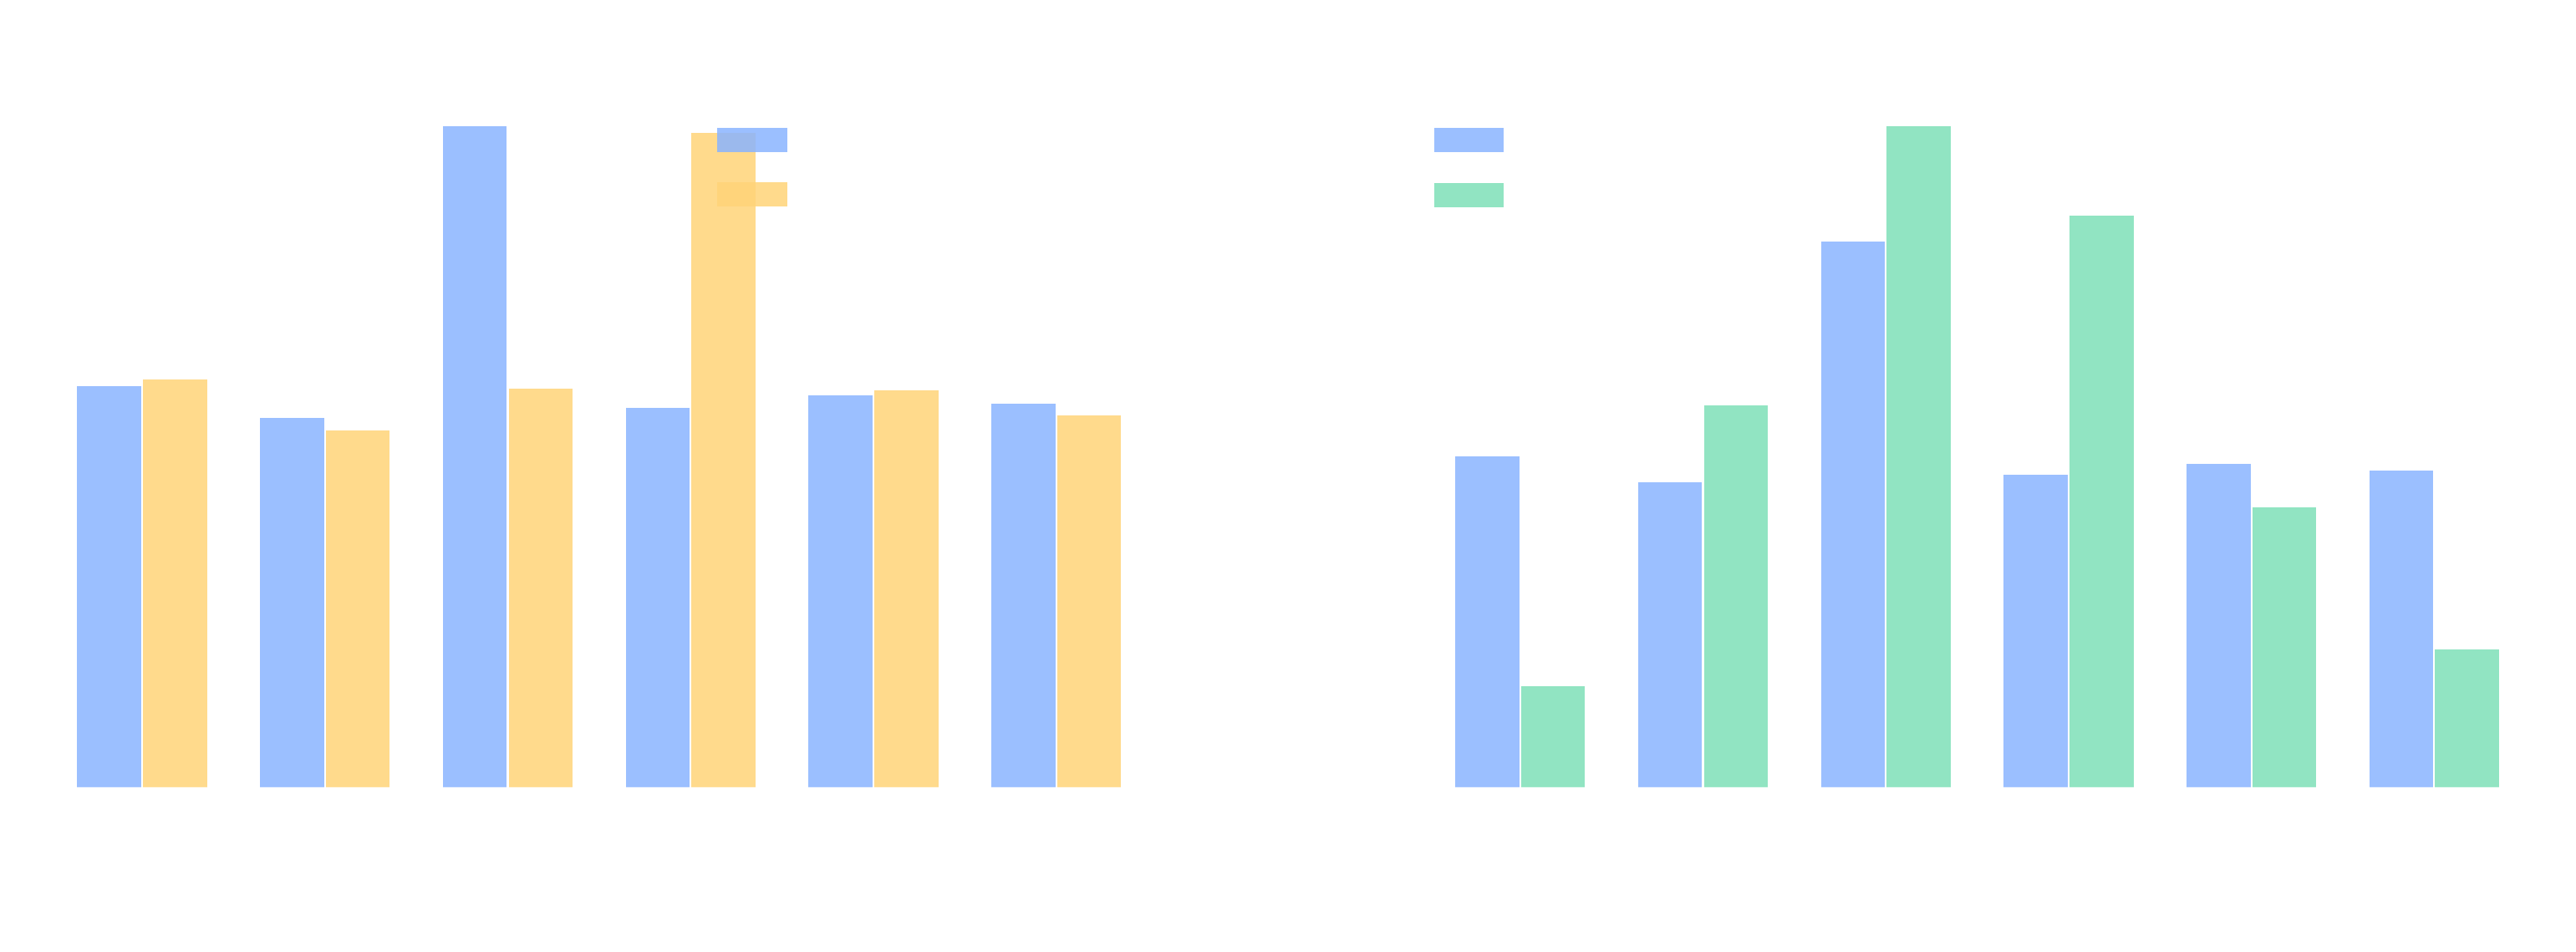

'slide_images/s2_samples.png'

In [148]:
def panel0(ax, s1, s2, m1, sd1, m2, sd2, l1, l2, c1, c2, title):
    f1 = np.array([np.mean(s1 == k) for k in faces]); f2 = np.array([np.mean(s2 == k) for k in faces])
    ax.bar(faces - 0.18, f1, width=0.35, color=c1, alpha=0.85, label=fr"{l1}:  $\mu={m1:g},\ \sigma={sd1:.2f}$")
    ax.bar(faces + 0.18, f2, width=0.35, color=c2, alpha=0.85, label=fr"{l2}:  $\mu={m2:g},\ \sigma={sd2:.2f}$")
    # for m, c in [(m1, c1), (m2, c2)]:
    #     ln = ax.axvline(m, color=c, lw=2.5); ln.set_path_effects([pe.withStroke(linewidth=5, foreground="white")])
    ax.set_xticks(faces); ax.set_yticks([]); ax.set_xlabel("die face"); ax.set_title(title); ax.legend(fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
panel0(axes[0], A, B, muA, sdA, muB, sdB, "A", "B", BLUE, GOLD,  "A vs B")
panel0(axes[1], A, C, muA, sdA, muC, sdC, "A", "C", BLUE, GREEN, "A vs C")
save(fig, "s2_samples")

## Step 1 — each sample mean is Gaussian (CLT)
$\bar A \sim N(\mu_A, \sigma^2/n)$, likewise $\bar B$. Far narrower than the raw data ($\sigma/\sqrt n$).

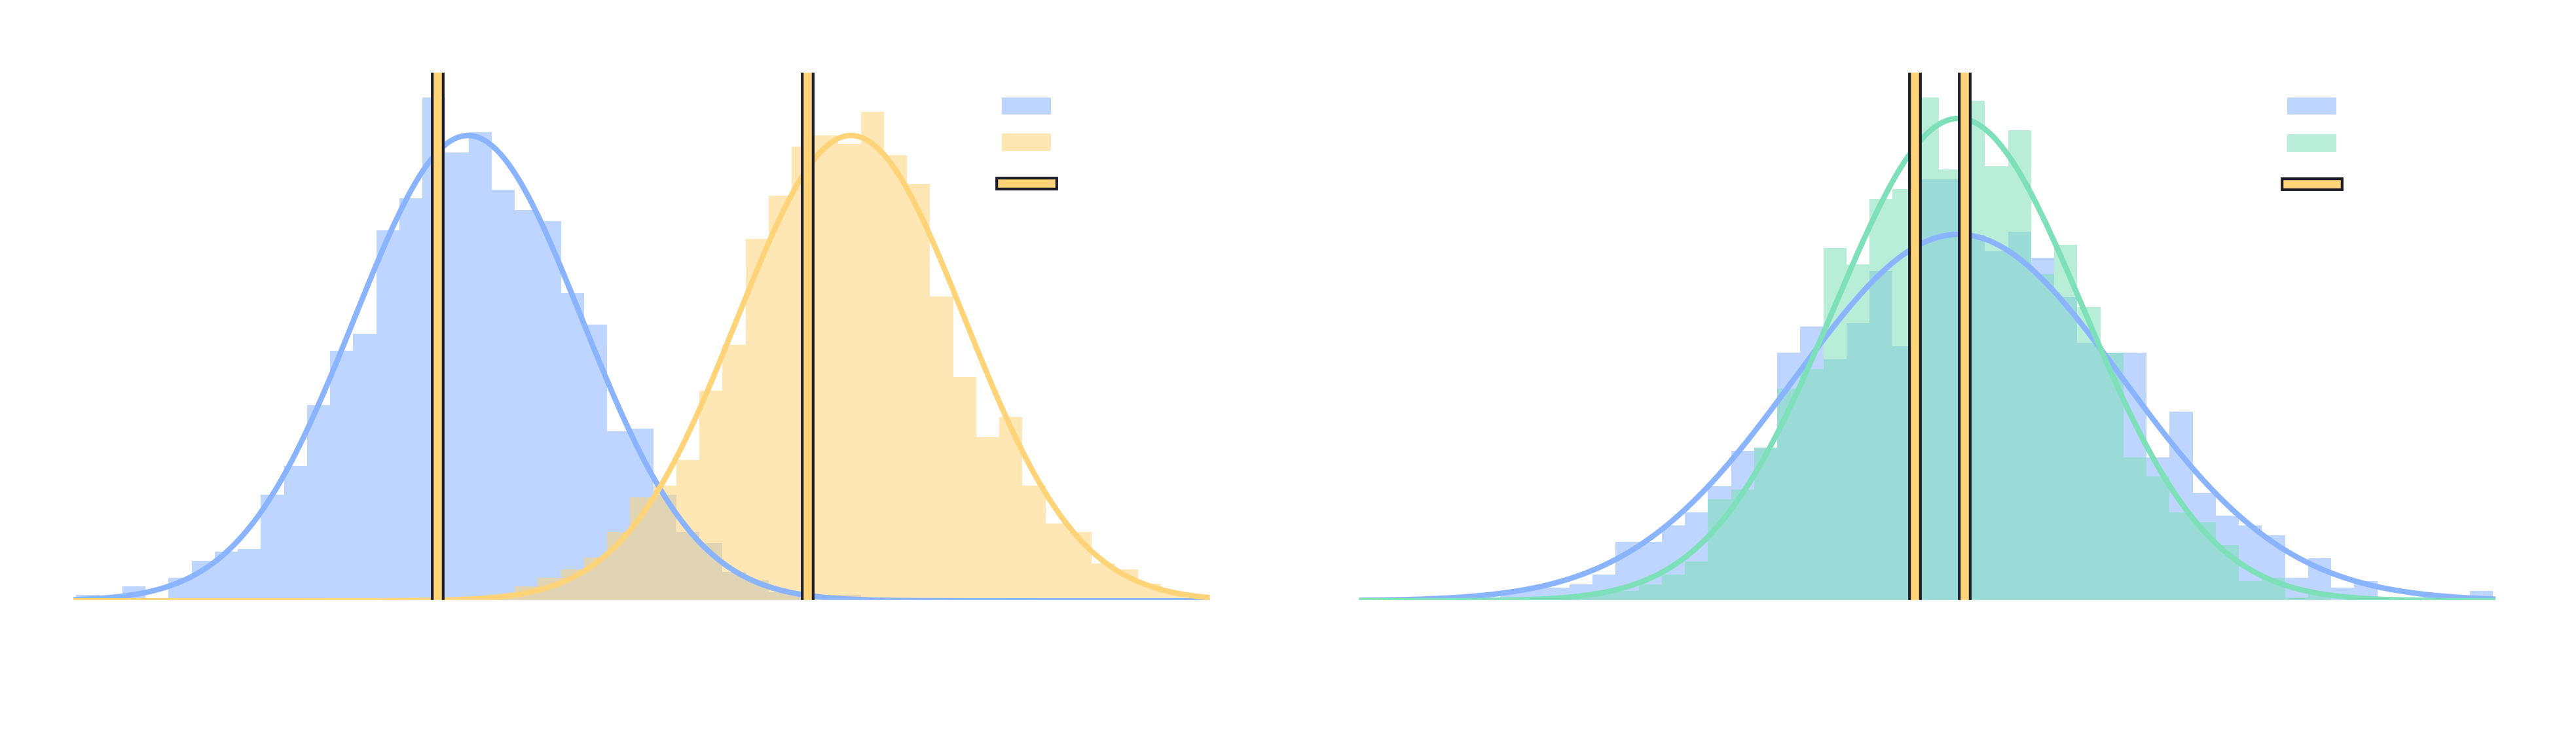

'slide_images/s2_means.png'

In [149]:
def panel1(ax, p1, m1, sd1, n1, om1, p2, m2, sd2, n2, om2, l1, l2, c1, c2, title):
    Ma = sample_means(p1, n1, M); Mb = sample_means(p2, n2, M)
    lo, hi = min(Ma.min(), Mb.min()), max(Ma.max(), Mb.max())
    bins = np.linspace(lo, hi, 50); x = np.linspace(lo, hi, 400)
    for mm, m, sdv, n, l, c in [(Ma, m1, sd1, n1, l1, c1), (Mb, m2, sd2, n2, l2, c2)]:
        ax.hist(mm, bins, density=True, alpha=0.55, color=c, label=fr"$\bar {{{l}}}$")
        ax.plot(x, stats.norm.pdf(x, m, sdv/np.sqrt(n)), color=c, lw=2)
    obsline(ax, om1, fr"observed $\bar {{{l1}}},\bar {{{l2}}}$"); obsline(ax, om2)
    ax.set_yticks([]); ax.set_xlabel("sample mean"); ax.set_title(title); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), constrained_layout=True)
panel1(axes[0], pA, muA, sdA, nA, obs_mA, pB, muB, sdB, nB, obs_mB, "A", "B", BLUE, GOLD,  r"$\bar A$ vs $\bar B$")
panel1(axes[1], pA, muA, sdA, nA, obs_mA, pC, muC, sdC, nC, obs_mC, "A", "C", BLUE, GREEN, r"$\bar A$ vs $\bar C$")
save(fig, "s2_means")

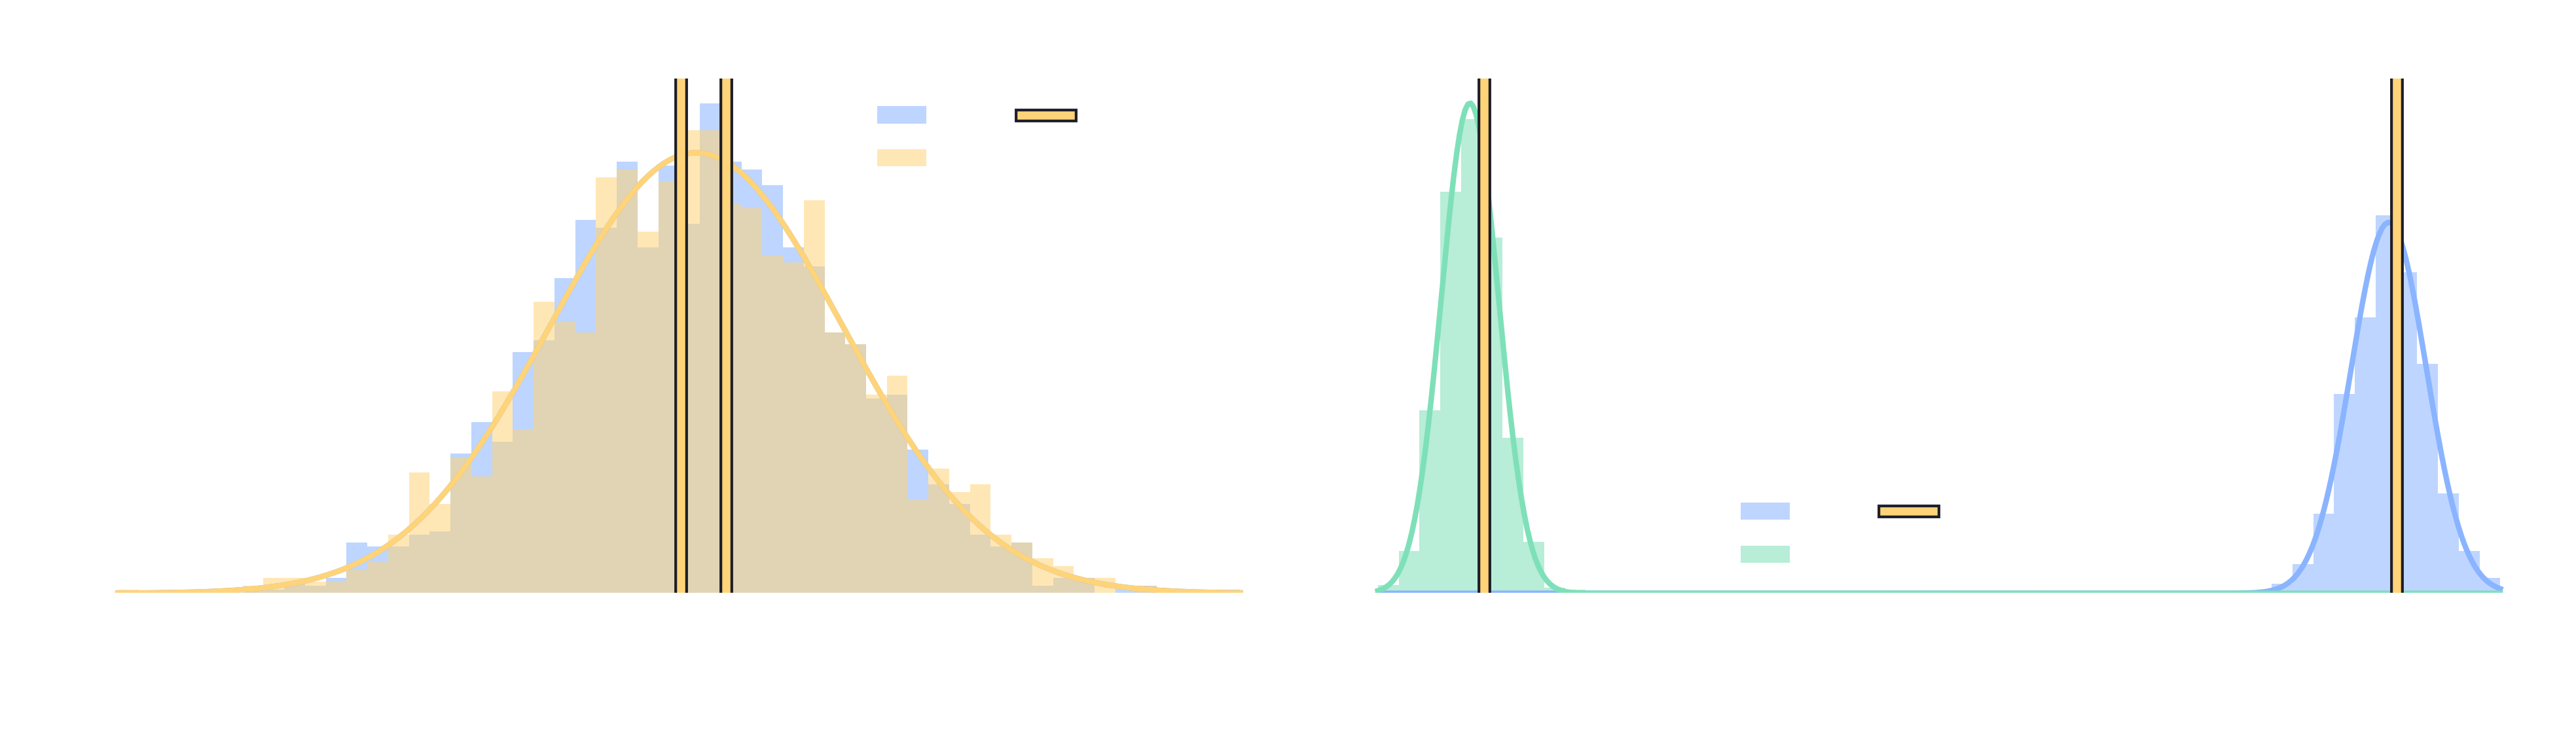

'slide_images/s2_vars.png'

In [150]:
def panel1v(ax, p1, v1, sv1, n1, ov1, p2, v2, sv2, n2, ov2, l1, l2, c1, c2, title):
    Sa = sample_vars(p1, n1, M); Sb = sample_vars(p2, n2, M)
    lo, hi = min(Sa.min(), Sb.min()), max(Sa.max(), Sb.max())
    bins = np.linspace(lo, hi, 55); x = np.linspace(lo, hi, 400)
    for ss, v, sv, l, c in [(Sa, v1, sv1, l1, c1), (Sb, v2, sv2, l2, c2)]:
        ax.hist(ss, bins, density=True, alpha=0.55, color=c, label=fr"$s_{{{l}}}^2$")
        ax.plot(x, stats.norm.pdf(x, v, sv), color=c, lw=2)
    obsline(ax, ov1, fr"observed $s_{{{l1}}}^2,s_{{{l2}}}^2$"); obsline(ax, ov2)
    ax.set_yticks([]); ax.set_xlabel(r"sample variance $s^2$"); ax.set_title(title); ax.legend(fontsize=9, ncol=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), constrained_layout=True)
panel1v(axes[0], pA, v2A, sdvA, nA, obs_vA, pB, v2B, sdvB, nB, obs_vB, "A", "B", BLUE, GOLD,  r"$s_A^2$ vs $s_B^2$")
panel1v(axes[1], pA, v2A, sdvA, nA, obs_vA, pC, v2C, sdvC, nC, obs_vC, "A", "C", BLUE, GREEN, r"$s_A^2$ vs $s_C^2$")
save(fig, "s2_vars")

## Steps 2-3 — the difference $D=\bar A-\bar B$, and its null
Difference of independent Gaussians is Gaussian and **variances add**. Under $H_0$ it recenters on 0.

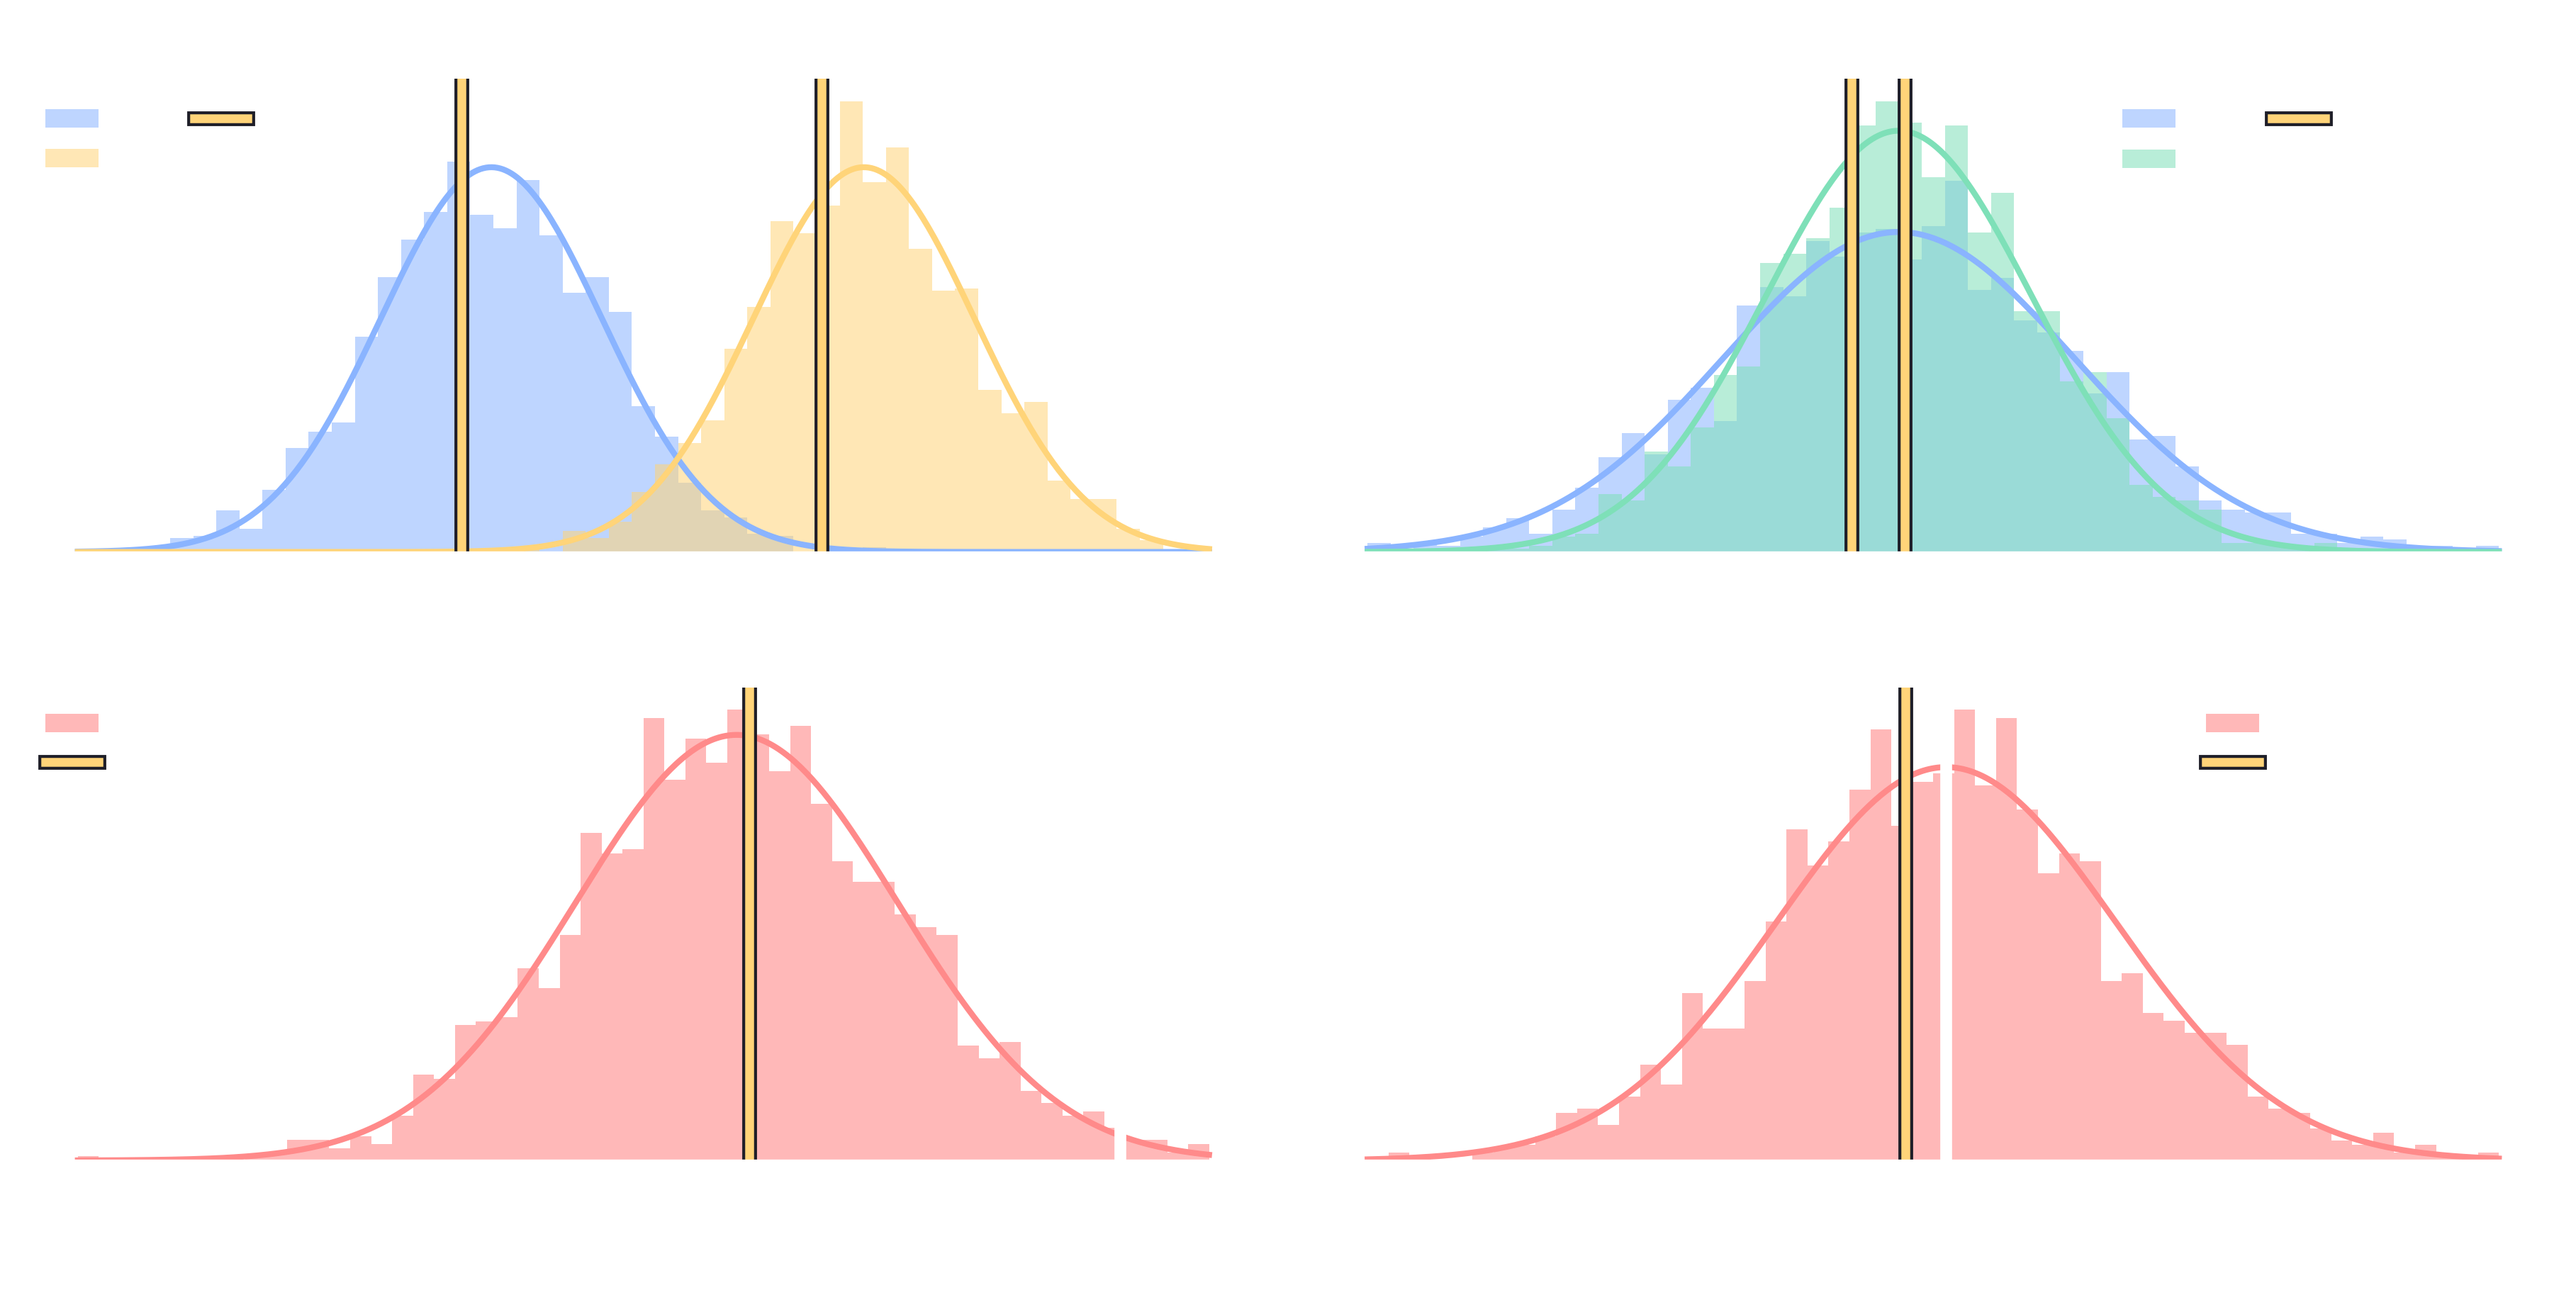

'slide_images/s2_diff.png'

In [153]:
TOP_XLIM = (3.30, 3.70)
TOP_TICKS = np.round(np.arange(3.3, 3.701, 0.1), 2)   # 3.3, 3.4, 3.5, 3.6, 3.7
def column(axtop, axbot, p1, m1, sd1, n1, om1, p2, m2, sd2, n2, om2, l1, l2, c1, c2, title):
    Ma = sample_means(p1, n1, M); Mb = sample_means(p2, n2, M); D = Ma - Mb
    lo, hi = min(Ma.min(), Mb.min()), max(Ma.max(), Mb.max())
    bins = np.linspace(lo, hi, 50); x = np.linspace(lo, hi, 400)
    for mm, m, sd, n, l, c in [(Ma, m1, sd1, n1, l1, c1), (Mb, m2, sd2, n2, l2, c2)]:
        axtop.hist(mm, bins, density=True, alpha=0.55, color=c, label=fr"$\bar {{{l}}}$")
        axtop.plot(x, stats.norm.pdf(x, m, sd/np.sqrt(n)), color=c, lw=2)
    obsline(axtop, om1, fr"observed $\bar {{{l1}}},\bar {{{l2}}}$"); obsline(axtop, om2)
    axtop.set_yticks([]); axtop.set_title(title); axtop.legend(fontsize=9, ncol=2); axtop.set_xlabel("sample mean")
    # axtop.set_xlim(*TOP_XLIM); axtop.set_xticks(TOP_TICKS)
    sdD = np.sqrt((sd1/np.sqrt(n1))**2 + (sd2/np.sqrt(n2))**2); obsD = om1 - om2
    b2 = np.linspace(min(D.min(), obsD), max(D.max(), obsD), 55); x2 = np.linspace(b2[0], b2[-1], 400)
    axbot.hist(D, b2, density=True, alpha=0.6, color=RED, label=fr"$D=\bar {{{l1}}}-\bar {{{l2}}}$")
    axbot.plot(x2, stats.norm.pdf(x2, m1 - m2, sdD), color=RED, lw=2)
    axbot.axvline(0, color="white", lw=4); obsline(axbot, obsD, fr"observed $D={obsD:+.2f}$")
    axbot.set_yticks([]); axbot.legend(fontsize=9); axbot.set_xlabel(fr"$\bar {{{l1}}}-\bar {{{l2}}}$")

fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
column(axes[0,0], axes[1,0], pA, muA, sdA, nA, obs_mA, pB, muB, sdB, nB, obs_mB, "A", "B", BLUE, GOLD,  r"$\bar A$ vs $\bar B$")
column(axes[0,1], axes[1,1], pA, muA, sdA, nA, obs_mA, pC, muC, sdC, nC, obs_mC, "A", "C", BLUE, GREEN, r"$\bar A$ vs $\bar C$")
save(fig, "s2_diff")

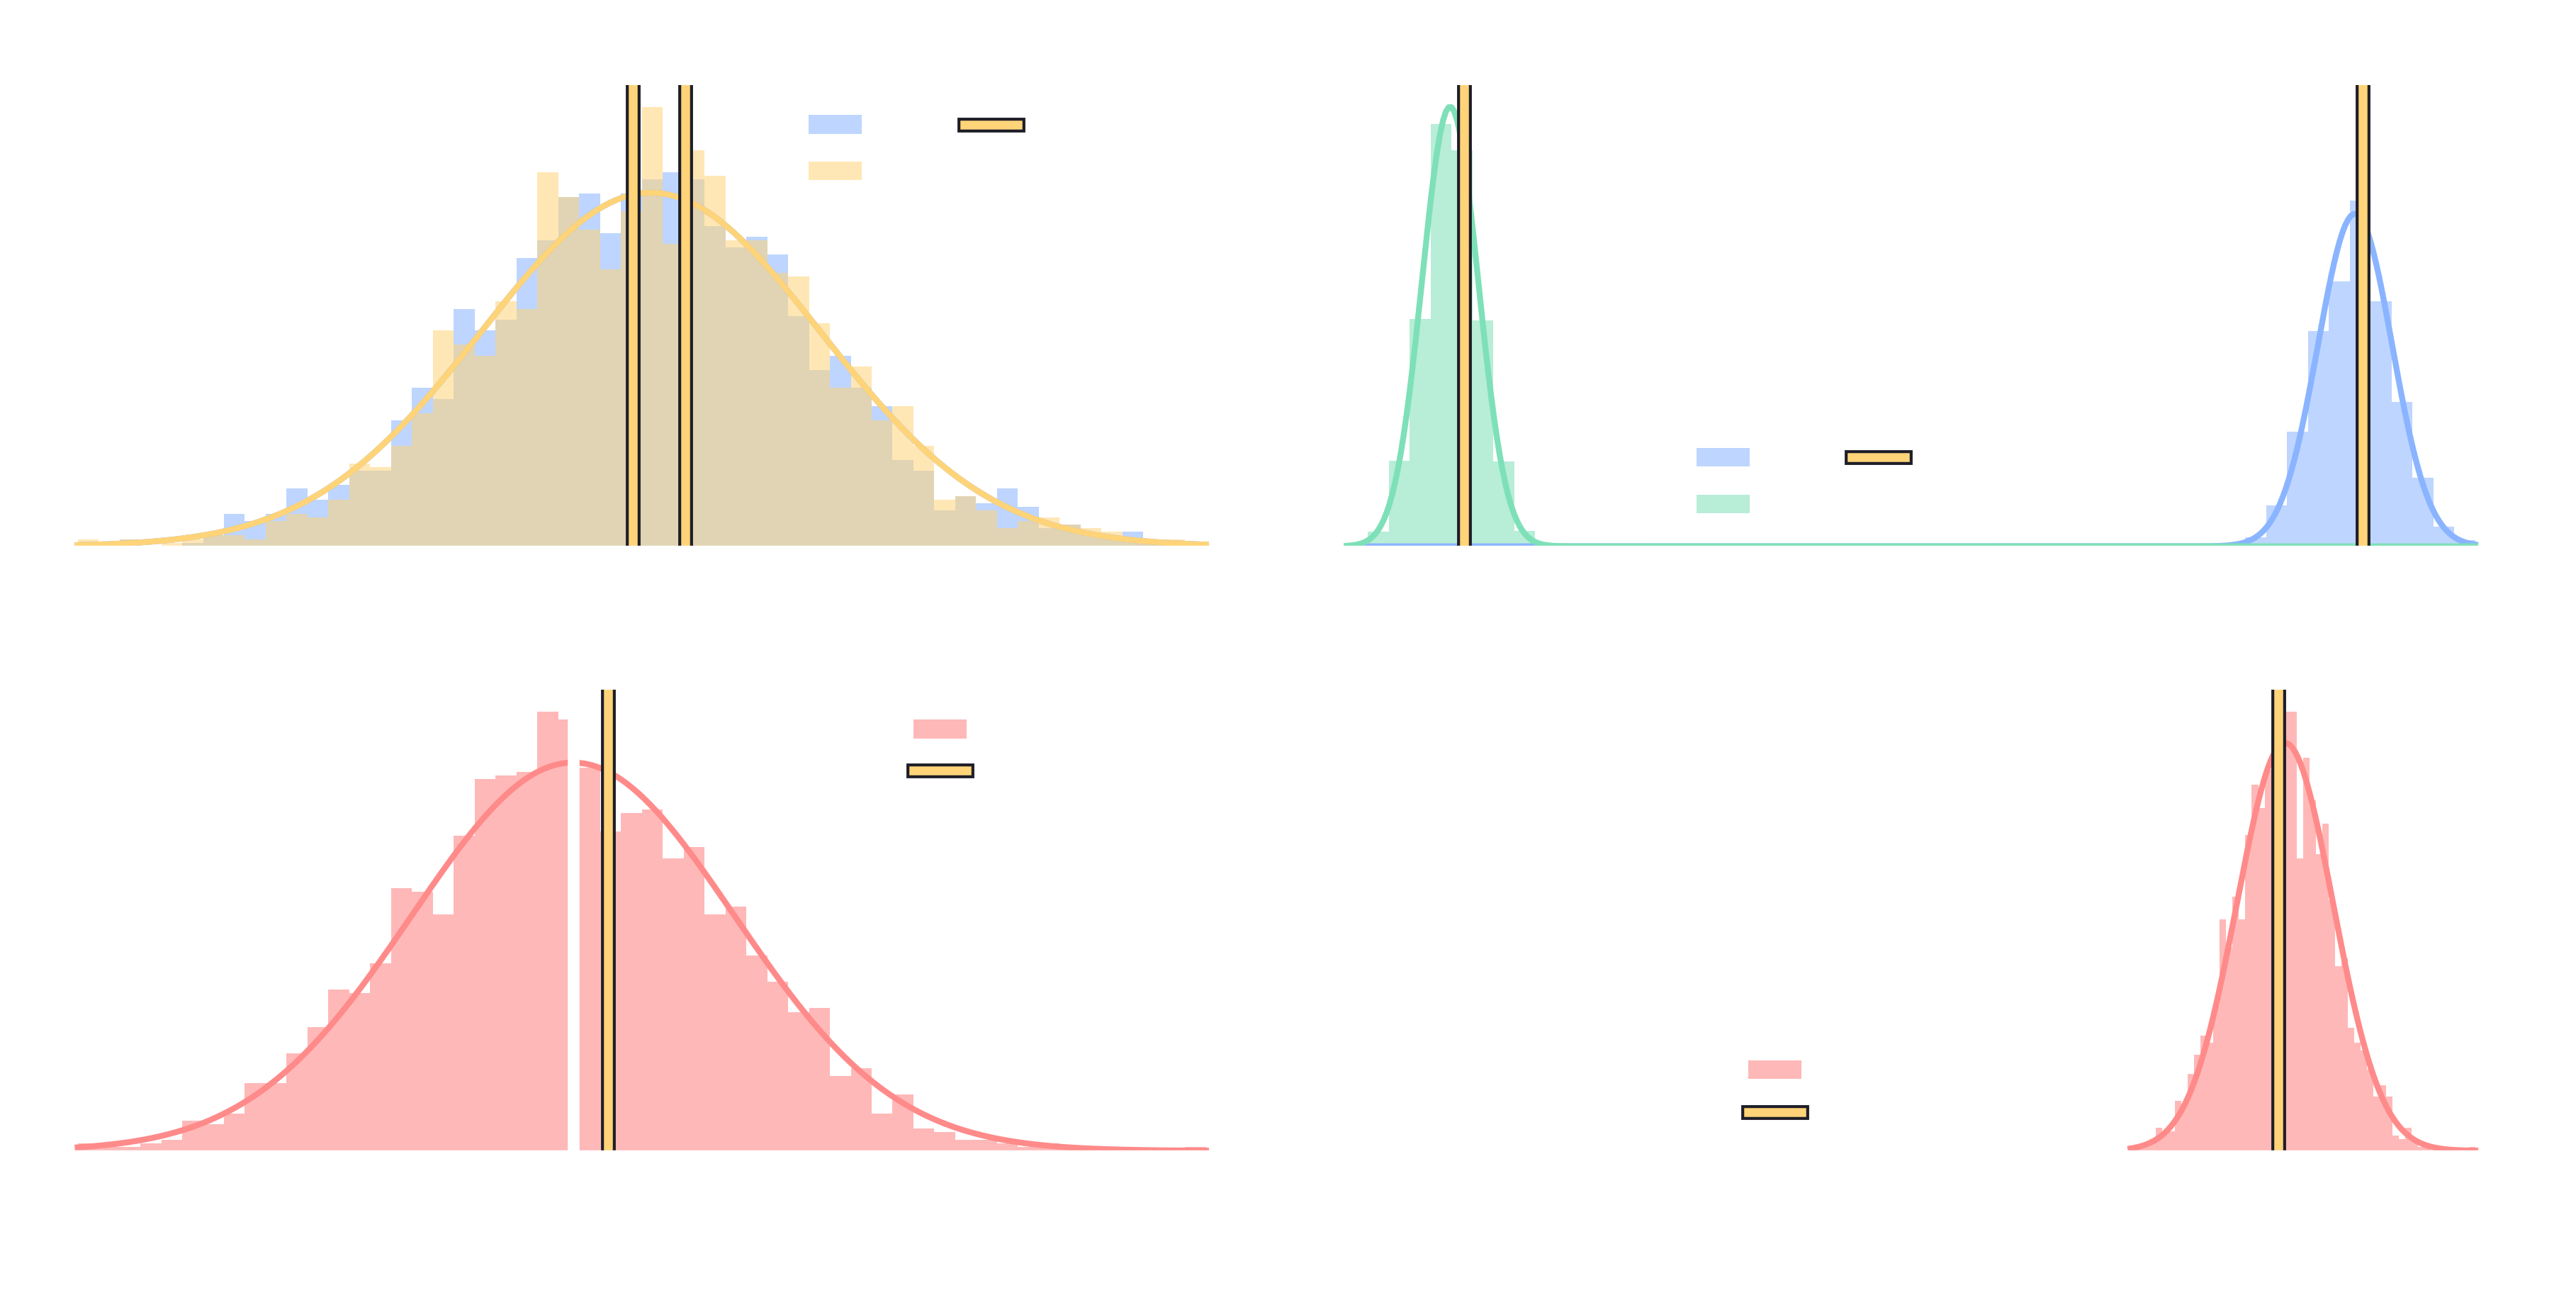

'slide_images/s2_vardiff.png'

In [154]:
def columnv(axtop, axbot, p1, v1, sv1, n1, ov1, p2, v2, sv2, n2, ov2, l1, l2, c1, c2, title):
    Sa = sample_vars(p1, n1, M); Sb = sample_vars(p2, n2, M); D = Sa - Sb
    lo, hi = min(Sa.min(), Sb.min()), max(Sa.max(), Sb.max())
    bins = np.linspace(lo, hi, 55); x = np.linspace(lo, hi, 400)
    for ss, v, sv, l, c in [(Sa, v1, sv1, l1, c1), (Sb, v2, sv2, l2, c2)]:
        axtop.hist(ss, bins, density=True, alpha=0.55, color=c, label=fr"$s_{{{l}}}^2$")
        axtop.plot(x, stats.norm.pdf(x, v, sv), color=c, lw=2)
    obsline(axtop, ov1, fr"observed $s_{{{l1}}}^2,s_{{{l2}}}^2$"); obsline(axtop, ov2)
    axtop.set_yticks([]); axtop.set_title(title); axtop.legend(fontsize=9, ncol=2); axtop.set_xlabel(r"sample variance $s^2$")
    sdD = np.sqrt(sv1**2 + sv2**2); obsD = ov1 - ov2
    b2 = np.linspace(min(D.min(), obsD), max(D.max(), obsD), 55); x2 = np.linspace(b2[0], b2[-1], 400)
    axbot.hist(D, b2, density=True, alpha=0.6, color=RED, label=fr"$D=s_{{{l1}}}^2-s_{{{l2}}}^2$")
    axbot.plot(x2, stats.norm.pdf(x2, v1 - v2, sdD), color=RED, lw=2)
    axbot.axvline(0, color="white", lw=4); obsline(axbot, obsD, fr"observed $D={obsD:+.2f}$")
    axbot.set_yticks([]); axbot.legend(fontsize=9); axbot.set_xlabel(fr"$s_{{{l1}}}^2-s_{{{l2}}}^2$")

fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
columnv(axes[0,0], axes[1,0], pA, v2A, sdvA, nA, obs_vA, pB, v2B, sdvB, nB, obs_vB, "A", "B", BLUE, GOLD,  r"$s_A^2$ vs $s_B^2$")
columnv(axes[0,1], axes[1,1], pA, v2A, sdvA, nA, obs_vA, pC, v2C, sdvC, nC, obs_vC, "A", "C", BLUE, GREEN, r"$s_A^2$ vs $s_C^2$")
save(fig, "s2_vardiff")

## Step 4 — Null
Difference of independent Gaussians is Gaussian and **variances add**. Under $H_0$ it recenters on 0.

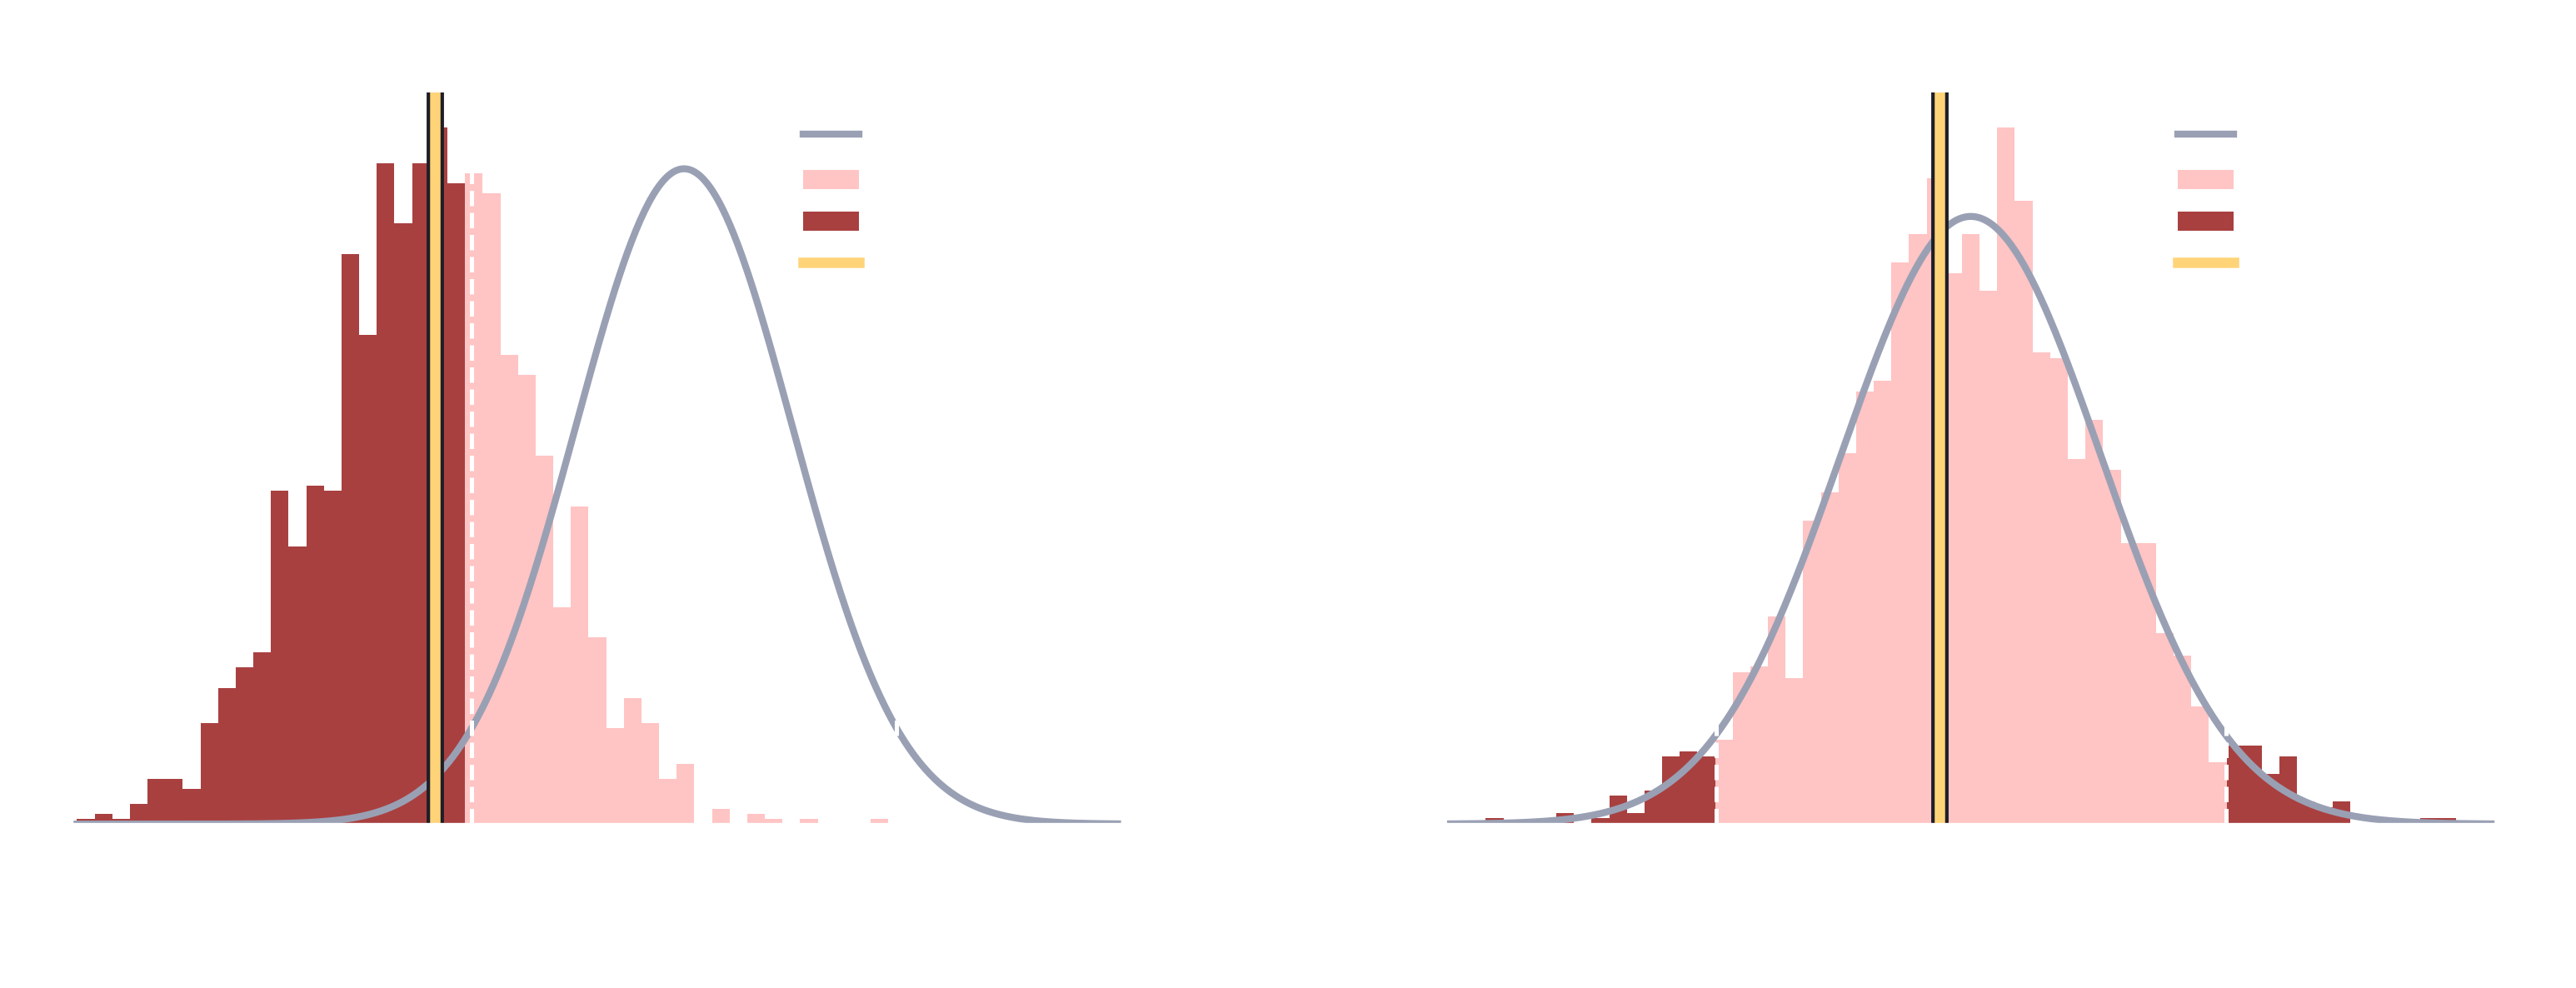

'slide_images/s2_null.png'

In [155]:
def panel4(ax, p1, m1, sd1, n1, om1, p2, m2, sd2, n2, om2, l1, l2, title):
    Ma = sample_means(p1, n1, M); Mb = sample_means(p2, n2, M); D = Ma - Mb
    sdD = np.sqrt((sd1/np.sqrt(n1))**2 + (sd2/np.sqrt(n2))**2); crit = 1.96*sdD; obsD = om1 - om2
    lo = min(D.min(), -4*sdD, obsD); hi = max(D.max(), 4*sdD, obsD)
    bins = np.linspace(lo, hi, 60); x = np.linspace(lo, hi, 500)
    ax.plot(x, stats.norm.pdf(x, 0, sdD), color=GREY, lw=2)            # null now grey
    counts, edges, patches = ax.hist(D, bins=bins, density=True)
    for c, pt in zip(0.5*(edges[:-1]+edges[1:]), patches):
        o = abs(c) >= crit; pt.set_facecolor(OUTRED if o else INRED); pt.set_alpha(0.9 if o else 0.5)
    for xc in (crit, -crit): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, obsD)
    ax.legend(handles=[
        Line2D([0], [0], color=GREY, lw=2, label=r"null $D\sim N(0,\sigma_D^2)$"),
        mpatches.Patch(facecolor=INRED, alpha=0.5, label=r"real $D$ inside"),
        mpatches.Patch(facecolor=OUTRED, alpha=0.9, label=r"real $D$ outside"),
        Line2D([0], [0], color=GOLD, lw=3, label=fr"observed $D={obsD:+.2f}$"),
    ], fontsize=8)
    ax.set_yticks([]); ax.set_xlabel(fr"$D=\bar {{{l1}}}-\bar {{{l2}}}$"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel4(axes[0], pA, muA, sdA, nA, obs_mA, pB, muB, sdB, nB, obs_mB, "A", "B", r"$\bar A$ vs $\bar B$")
panel4(axes[1], pA, muA, sdA, nA, obs_mA, pC, muC, sdC, nC, obs_mC, "A", "C", r"$\bar A$ vs $\bar C$")
save(fig, "s2_null")

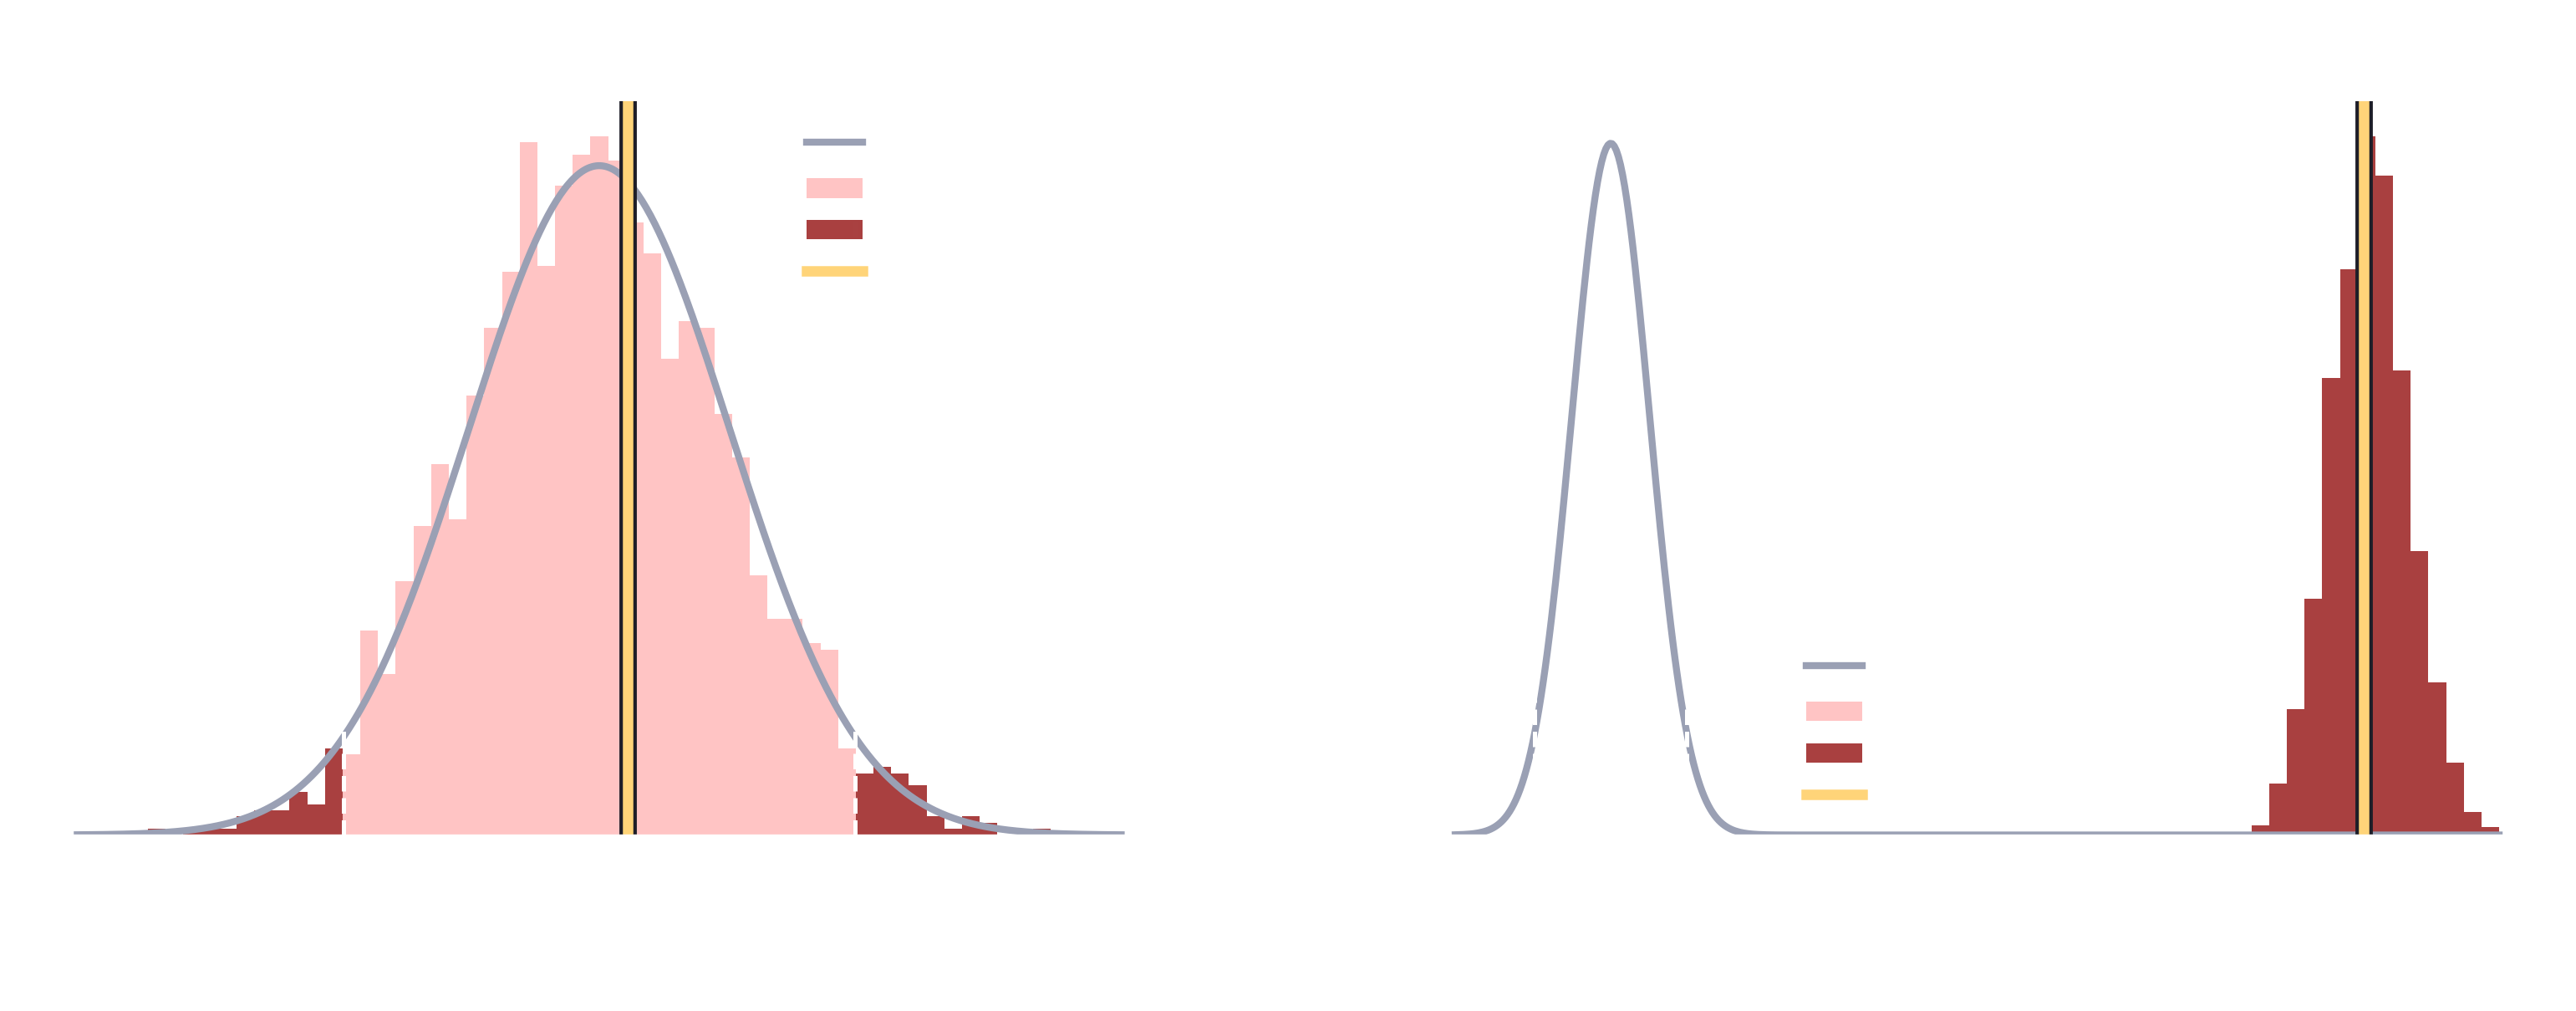

'slide_images/s2_null_var.png'

In [160]:
def panel4v(ax, p1, v1, sv1, n1, ov1, p2, v2, sv2, n2, ov2, l1, l2, title):
    Sa = sample_vars(p1, n1, M); Sb = sample_vars(p2, n2, M); D = Sa - Sb
    sdD = np.sqrt(sv1**2 + sv2**2); crit = 1.96*sdD; obsD = ov1 - ov2
    lo = min(D.min(), -4*sdD, obsD); hi = max(D.max(), 4*sdD, obsD)
    bins = np.linspace(lo, hi, 60); x = np.linspace(lo, hi, 500)
    ax.plot(x, stats.norm.pdf(x, 0, sdD), color=GREY, lw=2)
    counts, edges, patches = ax.hist(D, bins=bins, density=True)
    for c, pt in zip(0.5*(edges[:-1]+edges[1:]), patches):
        o = abs(c) >= crit; pt.set_facecolor(OUTRED if o else INRED); pt.set_alpha(0.9 if o else 0.5)
    for xc in (crit, -crit): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, obsD)
    ax.legend(handles=[Line2D([0],[0],color=GREY,lw=2,label=r"null $D\sim N(0,\sigma_D^2)$"),
        mpatches.Patch(facecolor=INRED,alpha=0.5,label=r"real $D$ inside"),
        mpatches.Patch(facecolor=OUTRED,alpha=0.9,label=r"real $D$ outside"),
        Line2D([0],[0],color=GOLD,lw=3,label=fr"observed $D={obsD:+.2f}$")], fontsize=8)
    ax.set_yticks([]); ax.set_xlabel(fr"$D=s_{{{l1}}}^2-s_{{{l2}}}^2$"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel4v(axes[0], pA, v2A, sdvA, nA, obs_vA, pB, v2B, sdvB, nB, obs_vB, "A", "B", r"$s_A^2$ vs $s_B^2$")
panel4v(axes[1], pA, v2A, sdvA, nA, obs_vA, pC, v2C, sdvC, nC, obs_vC, "A", "C", r"$s_A^2$ vs $s_C^2$")
save(fig, "s2_null_var")

## Step 5 — standardize -> two-sample z-test (two-tailed)
$Z=\dfrac{\bar A-\bar B}{\sqrt{\sigma_A^2/n_A+\sigma_B^2/n_B}}\sim N(0,1)$ under $H_0$. A difference in *either* direction counts, so both tails reject.

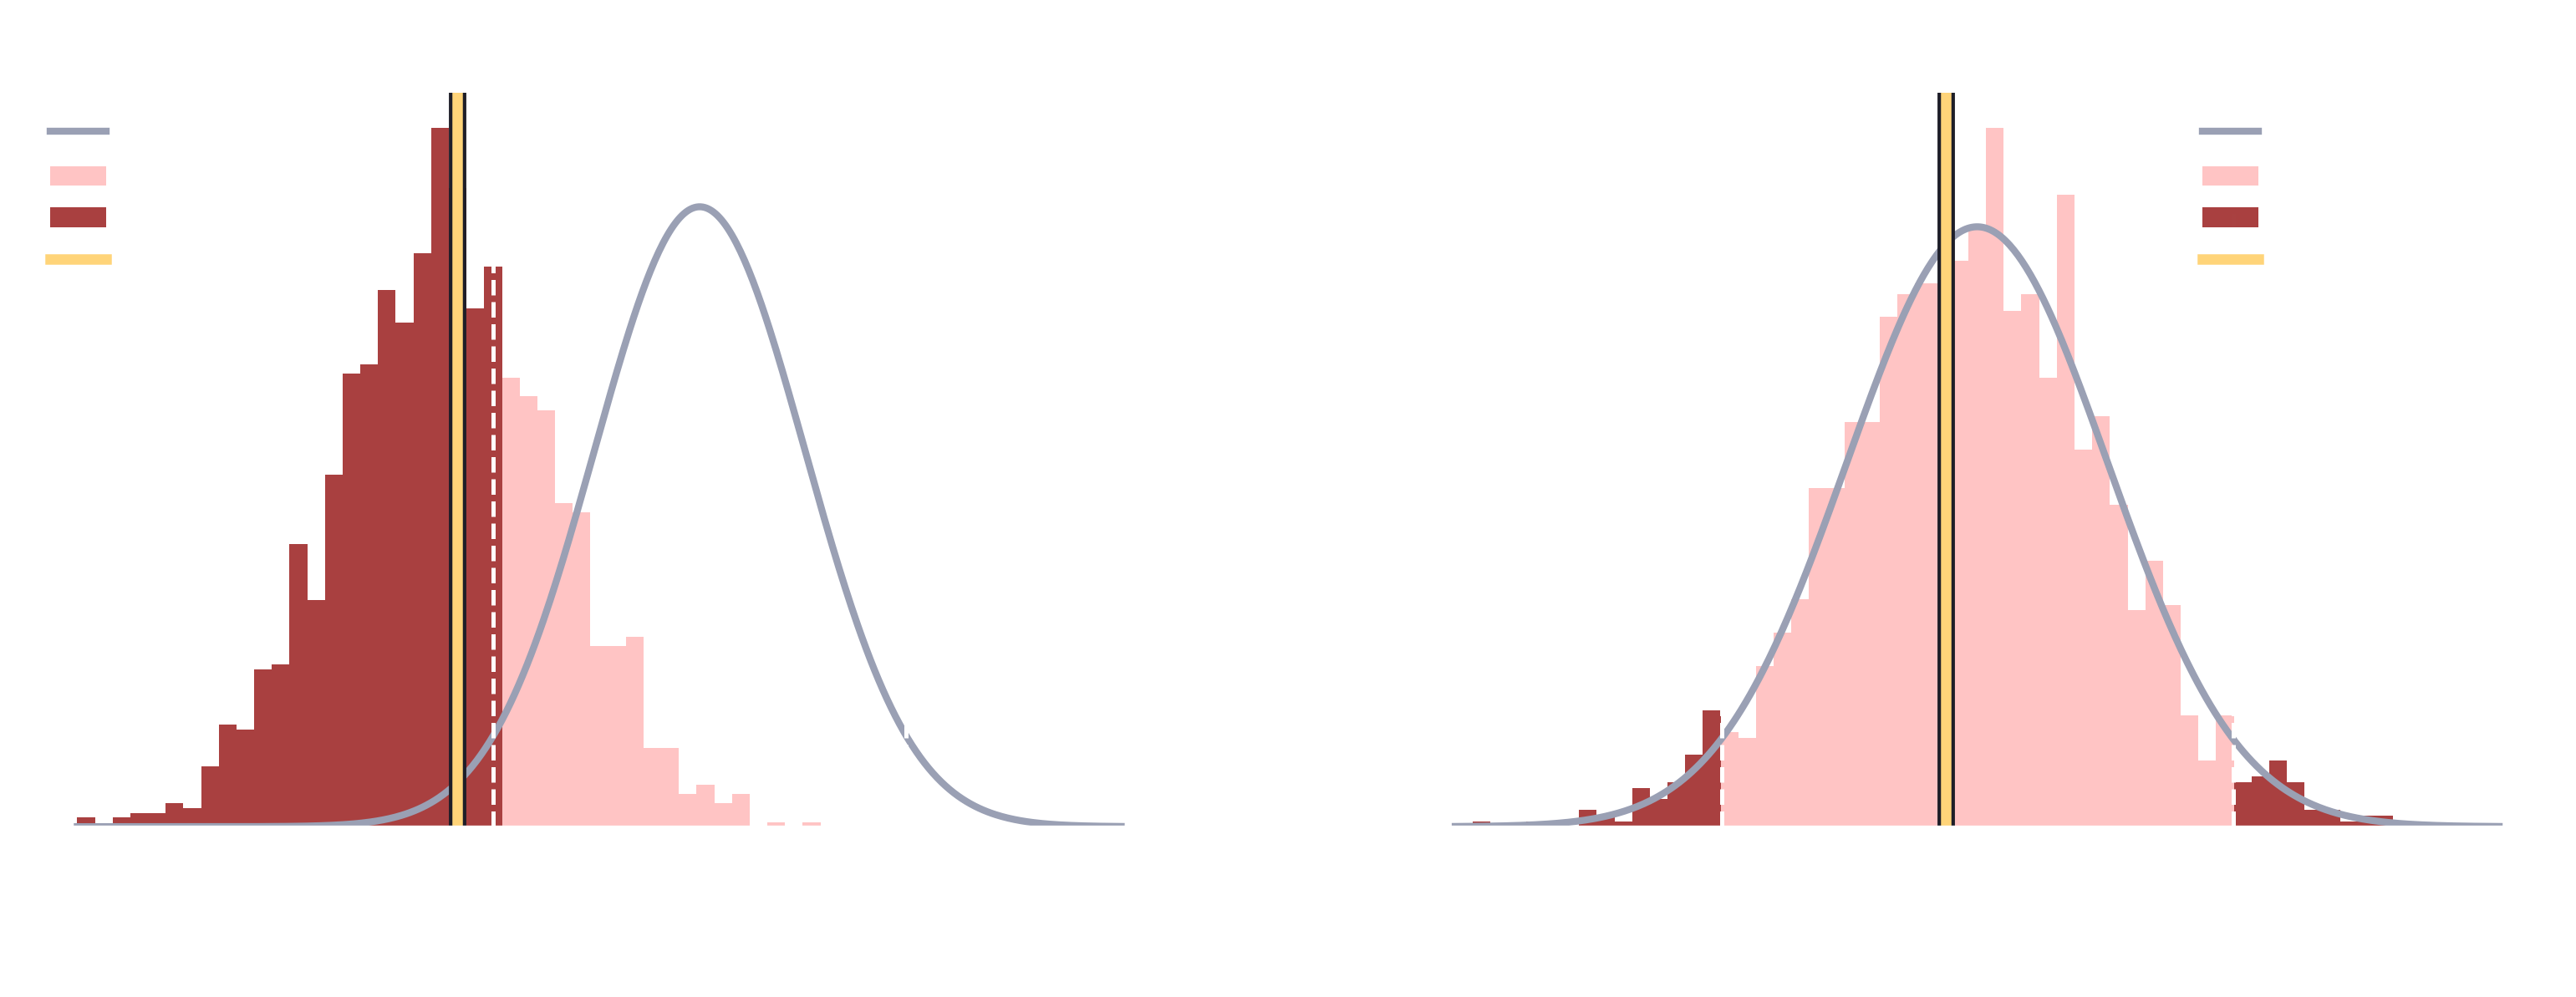

'slide_images/s2_standardize.png'

In [156]:
def panel5(ax, p1, n1, om1, ov1, p2, n2, om2, ov2, l1, l2, title):
    Ma, Va = sample_mv(p1, n1, M); Mb, Vb = sample_mv(p2, n2, M)
    Z = (Ma - Mb) / np.sqrt(Va/n1 + Vb/n2); crit = 1.96
    obsZ = (om1 - om2) / np.sqrt(ov1/n1 + ov2/n2)
    lo = min(Z.min(), -4, obsZ); hi = max(Z.max(), 4, obsZ)
    bins = np.linspace(lo, hi, 60); x = np.linspace(lo, hi, 500)
    ax.plot(x, stats.norm.pdf(x), color=GREY, lw=2)
    counts, edges, patches = ax.hist(Z, bins=bins, density=True)
    for c, pt in zip(0.5*(edges[:-1]+edges[1:]), patches):
        o = abs(c) >= crit; pt.set_facecolor(OUTRED if o else INRED); pt.set_alpha(0.9 if o else 0.5)
    for xc in (crit, -crit): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, obsZ)
    ax.legend(handles=[
        Line2D([0], [0], color=GREY, lw=2, label=r"null $Z\sim N(0,1)$"),
        mpatches.Patch(facecolor=INRED, alpha=0.5, label="real $Z$ inside"),
        mpatches.Patch(facecolor=OUTRED, alpha=0.9, label="real $Z$ outside"),
        Line2D([0], [0], color=GOLD, lw=3, label=fr"observed $Z={obsZ:+.1f}$"),
    ], fontsize=8)
    ax.set_yticks([]); ax.set_xlabel(r"$Z=D/s_D$"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel5(axes[0], pA, nA, obs_mA, obs_vA, pB, nB, obs_mB, obs_vB, "A", "B", r"$\bar A$ vs $\bar B$")
panel5(axes[1], pA, nA, obs_mA, obs_vA, pC, nC, obs_mC, obs_vC, "A", "C", r"$\bar A$ vs $\bar C$")
save(fig, "s2_standardize")

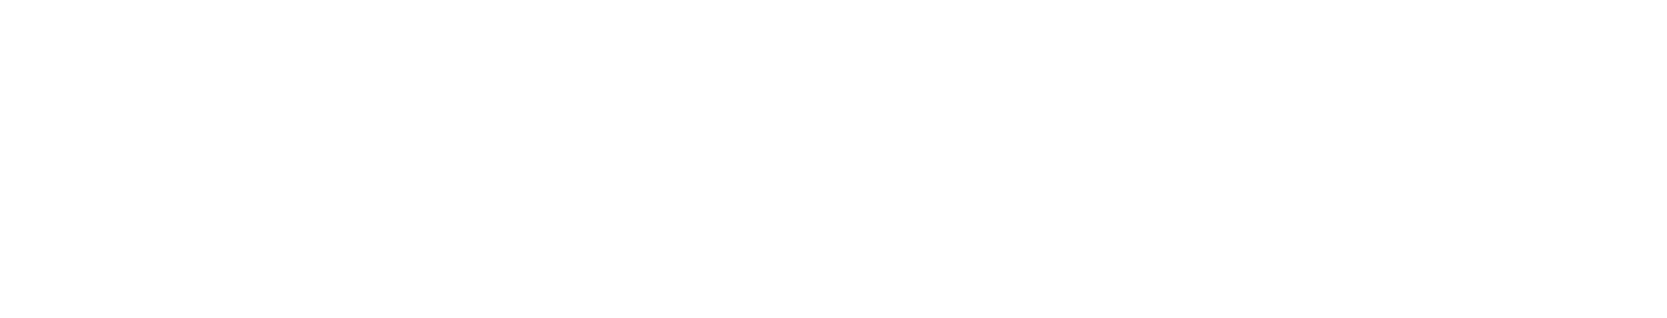

'slide_images/eq_Z.png'

In [145]:
eq(r"""$\displaystyle
Z=\frac{\bar A-\bar B}{\sqrt{s_A^2/n_A+s_B^2/n_B}}\ =\frac{D}{s_D} \overset{H_0}{\sim}\ \ N(0,1)$""", "eq_Z", r=600)

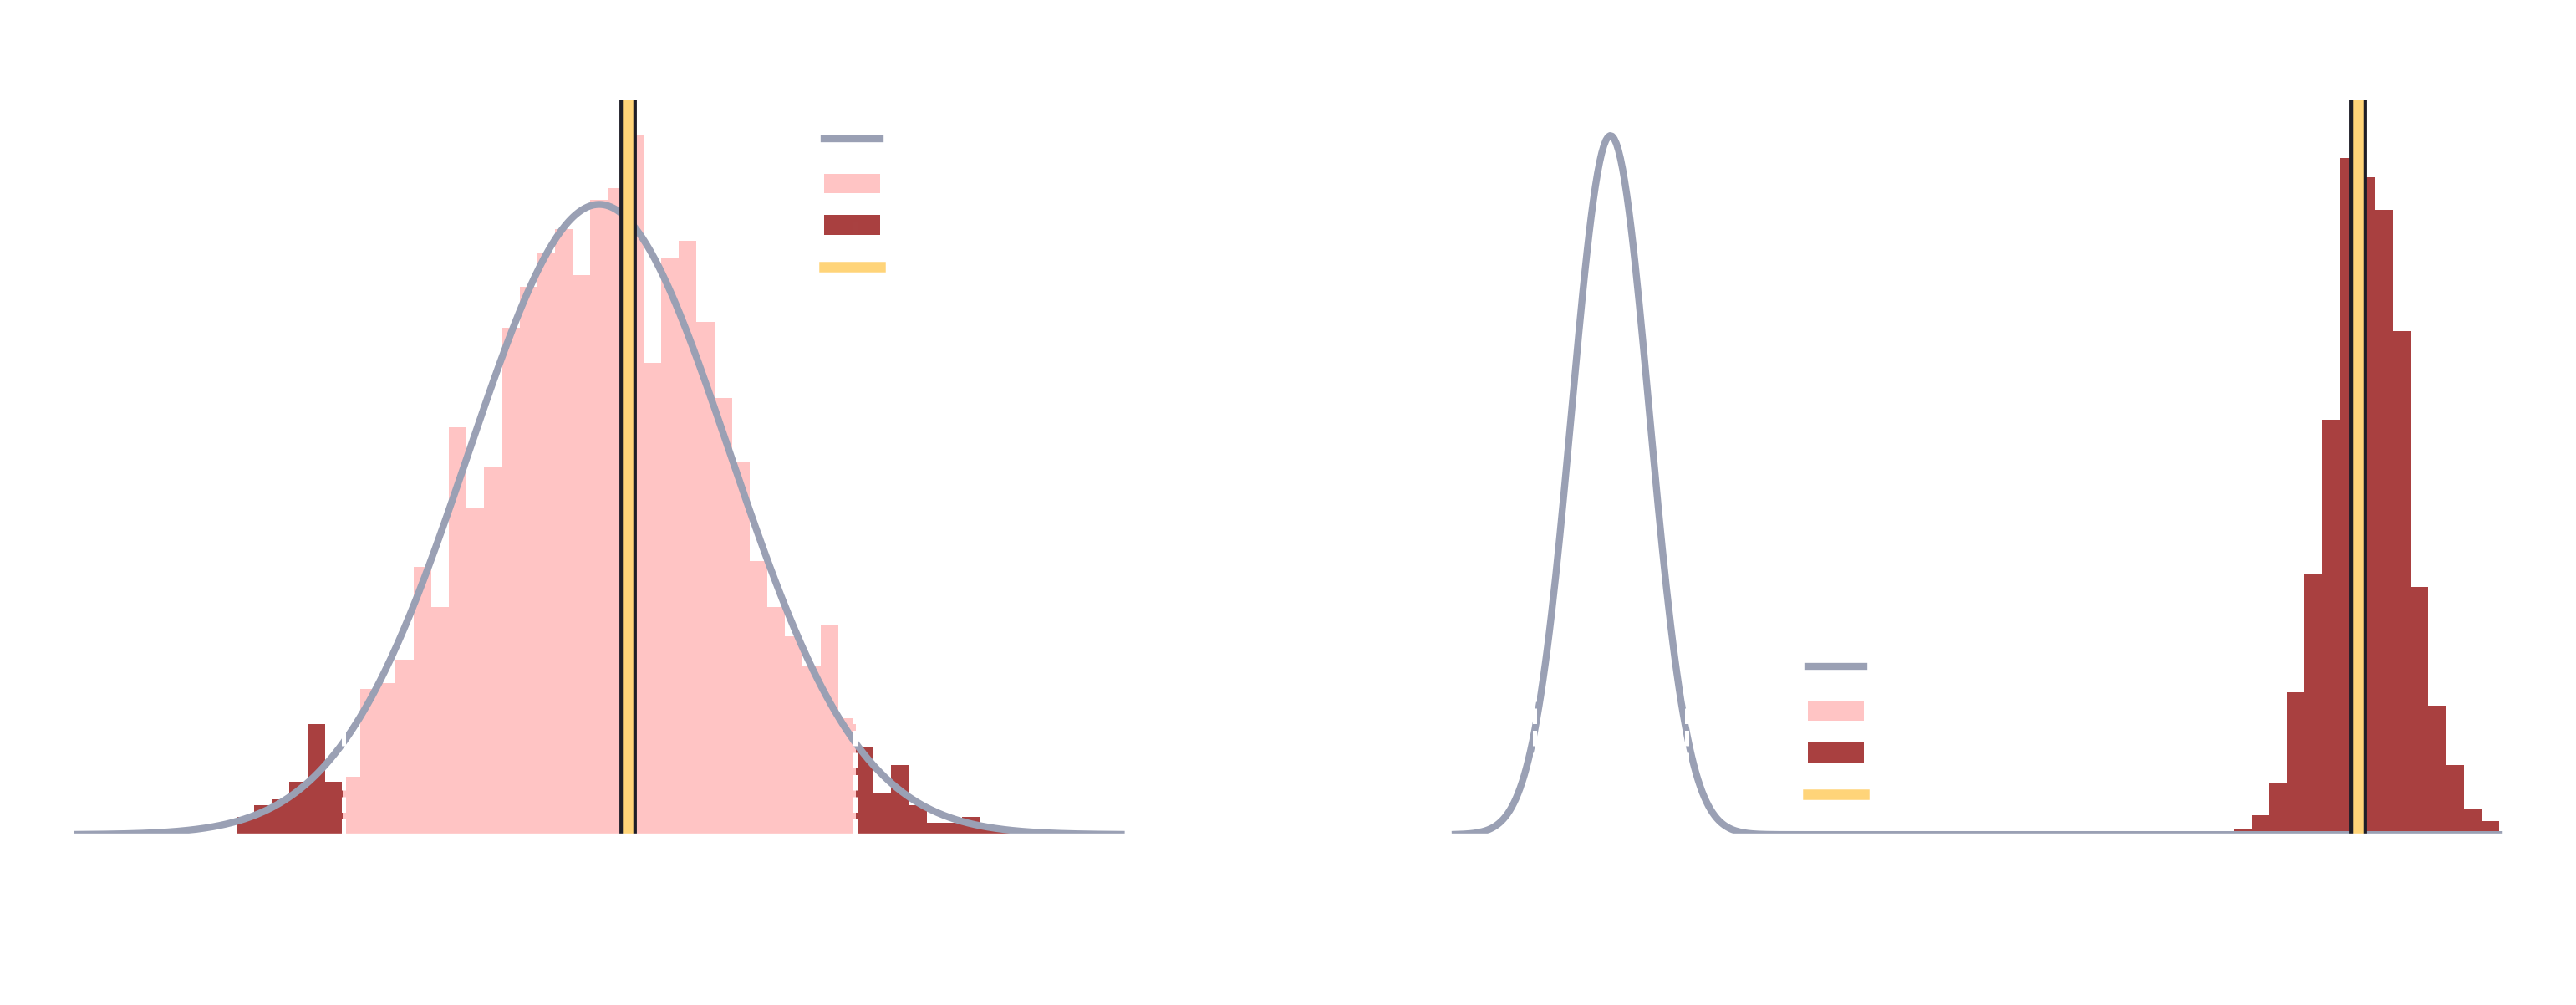

'slide_images/s2_standardize_var.png'

In [161]:
def panel5v(ax, p1, n1, os1, p2, n2, os2, l1, l2, title):
    m2a, sea = sample_var_se(p1, n1, M); m2b, seb = sample_var_se(p2, n2, M)
    Zv = (m2a - m2b) / np.sqrt(sea**2 + seb**2); crit = 1.96
    ov1, se1 = obs_var_se(os1, n1); ov2, se2 = obs_var_se(os2, n2)
    obsZ = (ov1 - ov2) / np.sqrt(se1**2 + se2**2)
    lo = min(Zv.min(), -4, obsZ); hi = max(Zv.max(), 4, obsZ)
    bins = np.linspace(lo, hi, 60); x = np.linspace(lo, hi, 500)
    ax.plot(x, stats.norm.pdf(x), color=GREY, lw=2)
    counts, edges, patches = ax.hist(Zv, bins=bins, density=True)
    for c, pt in zip(0.5*(edges[:-1]+edges[1:]), patches):
        o = abs(c) >= crit; pt.set_facecolor(OUTRED if o else INRED); pt.set_alpha(0.9 if o else 0.5)
    for xc in (crit, -crit): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, obsZ)
    ax.legend(handles=[Line2D([0],[0],color=GREY,lw=2,label=r"null $Z\sim N(0,1)$"),
        mpatches.Patch(facecolor=INRED,alpha=0.5,label="real $Z$ inside"),
        mpatches.Patch(facecolor=OUTRED,alpha=0.9,label="real $Z$ outside"),
        Line2D([0],[0],color=GOLD,lw=3,label=fr"observed $Z={obsZ:+.1f}$")], fontsize=8)
    ax.set_yticks([]); ax.set_xlabel(r"$Z=D/s_D$"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel5v(axes[0], pA, nA, A, pB, nB, B, "A", "B", r"$s_A^2$ vs $s_B^2$")
panel5v(axes[1], pA, nA, A, pC, nC, C, "A", "C", r"$s_A^2$ vs $s_C^2$")
save(fig, "s2_standardize_var")

## Step 6 — permutation test: the null with no theory
If the labels are meaningless under $H_0$, pool everything and reshuffle labels thousands of times. The histogram of shuffled mean-differences **is** the null distribution -- and the analytic Gaussian the CLT predicted lands right on top of it.

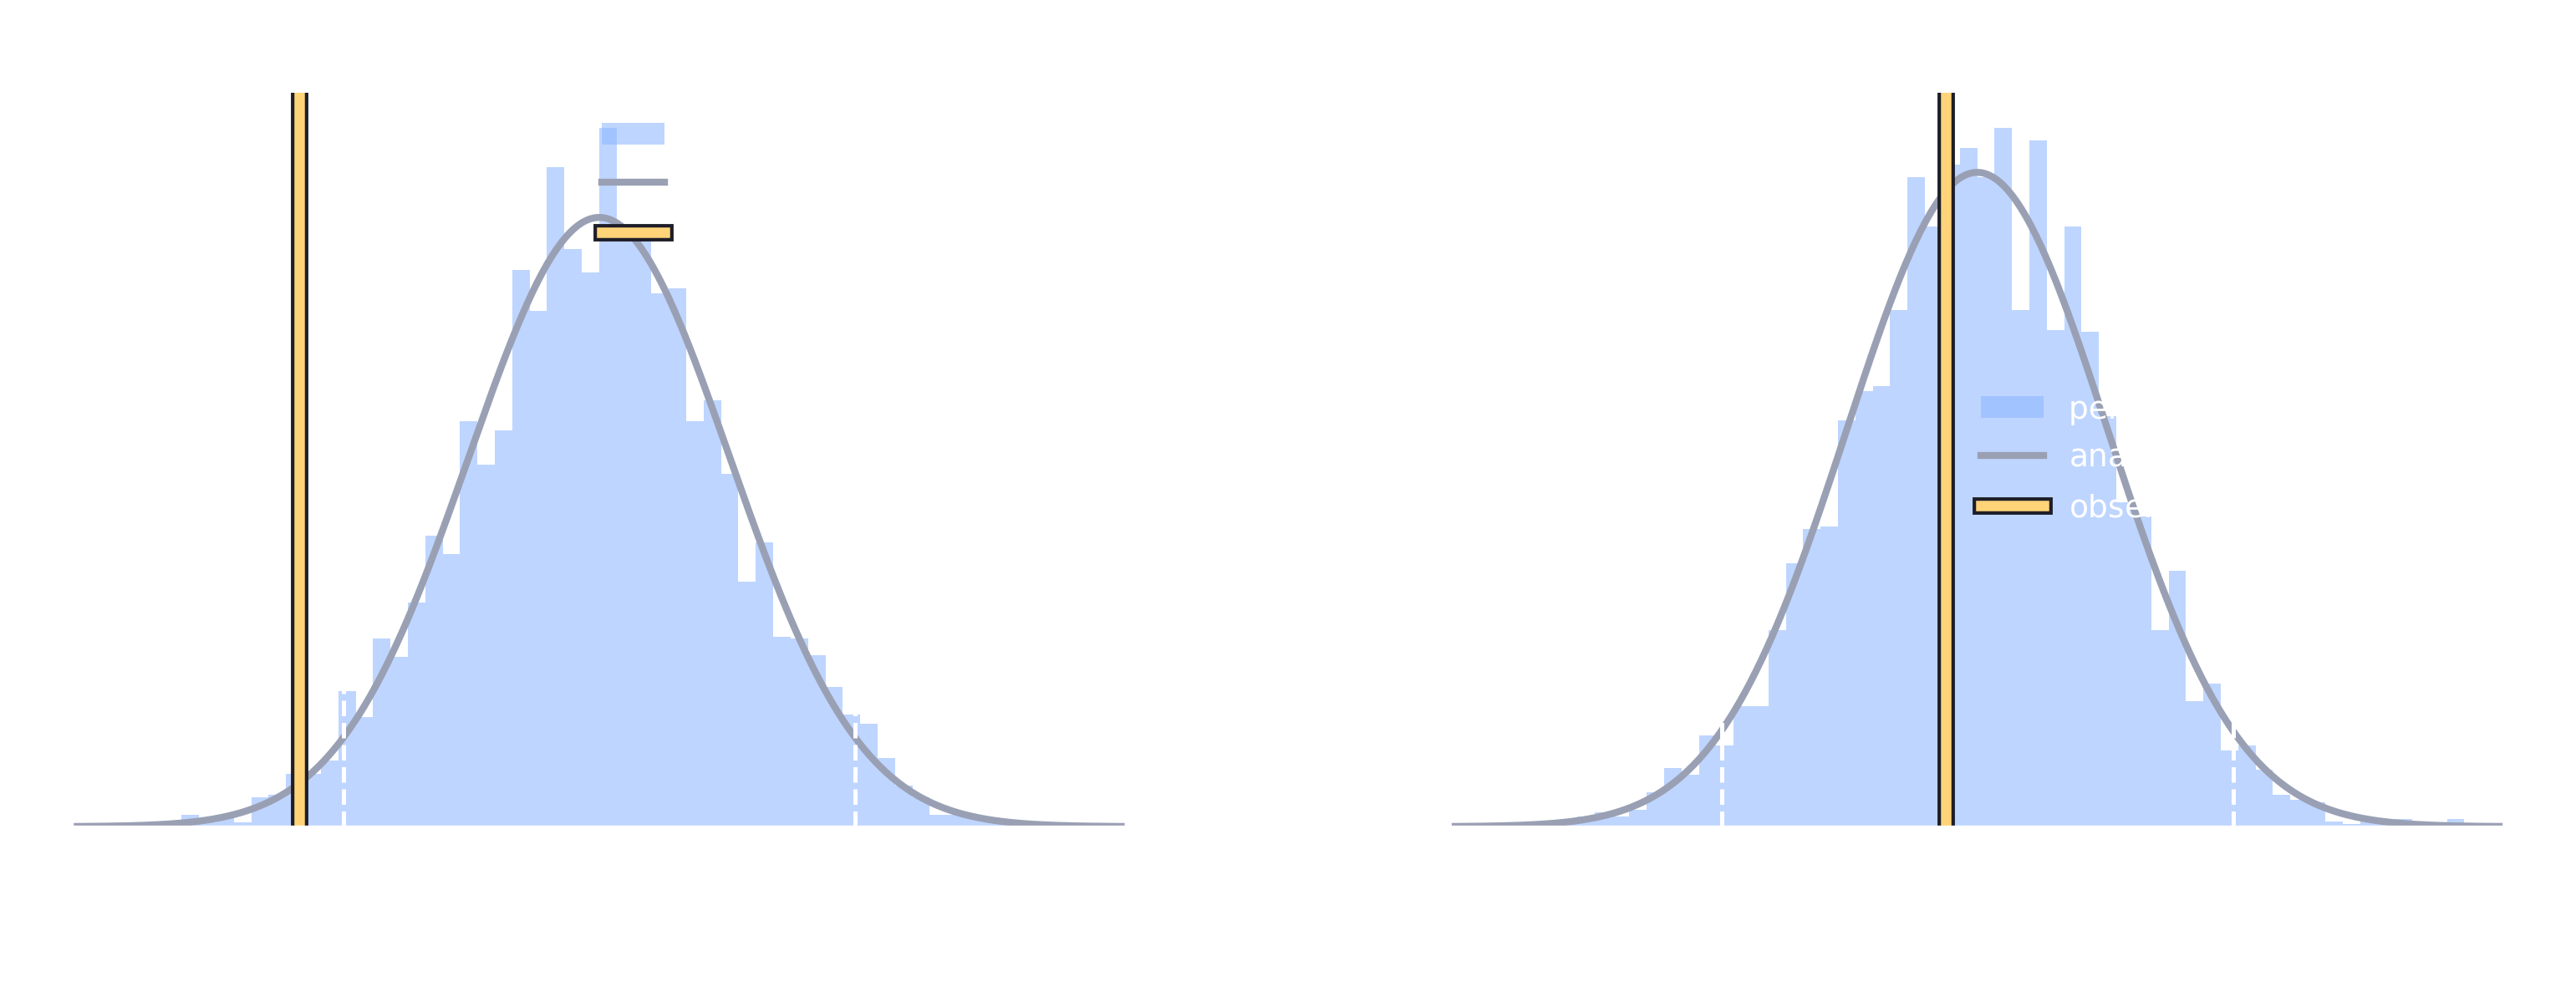

'slide_images/s2_permutation.png'

In [158]:
P = 5000
def panel6(ax, s1, s2, title):
    pooled = np.concatenate([s1, s2]); n1 = len(s1); n2 = len(s2); N = n1 + n2
    idx = np.argsort(rng.random((P, N)), axis=1); sh = pooled[idx]      # vectorized label shuffles
    a = sh[:, :n1]; b = sh[:, n1:]
    Zp = (a.mean(1) - b.mean(1)) / np.sqrt(a.var(ddof=1, axis=1)/n1 + b.var(ddof=1, axis=1)/n2)   # studentize each shuffle
    obsZ = (s1.mean() - s2.mean()) / np.sqrt(s1.var(ddof=1)/n1 + s2.var(ddof=1)/n2)
    pval = np.mean(np.abs(Zp) >= abs(obsZ))
    lo = min(Zp.min(), -4, obsZ); hi = max(Zp.max(), 4, obsZ)
    ax.hist(Zp, bins=60, range=(lo, hi), density=True, color=BLUE, alpha=0.55, label="permutation null (shuffled)")
    x = np.linspace(lo, hi, 400); ax.plot(x, stats.norm.pdf(x), color=GREY, lw=2, label=r"analytic $N(0,1)$")
    for xc in (1.96, -1.96): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, obsZ, fr"observed $Z={obsZ:+.1f}$  (p={pval:.3f})")
    ax.set_yticks([]); ax.set_xlabel(r"$Z=D/s_D$"); ax.set_title(title); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel6(axes[0], A, B, r"$\bar A$ vs $\bar B$")
panel6(axes[1], A, C, r"$\bar A$ vs $\bar C$")
save(fig, "s2_permutation")

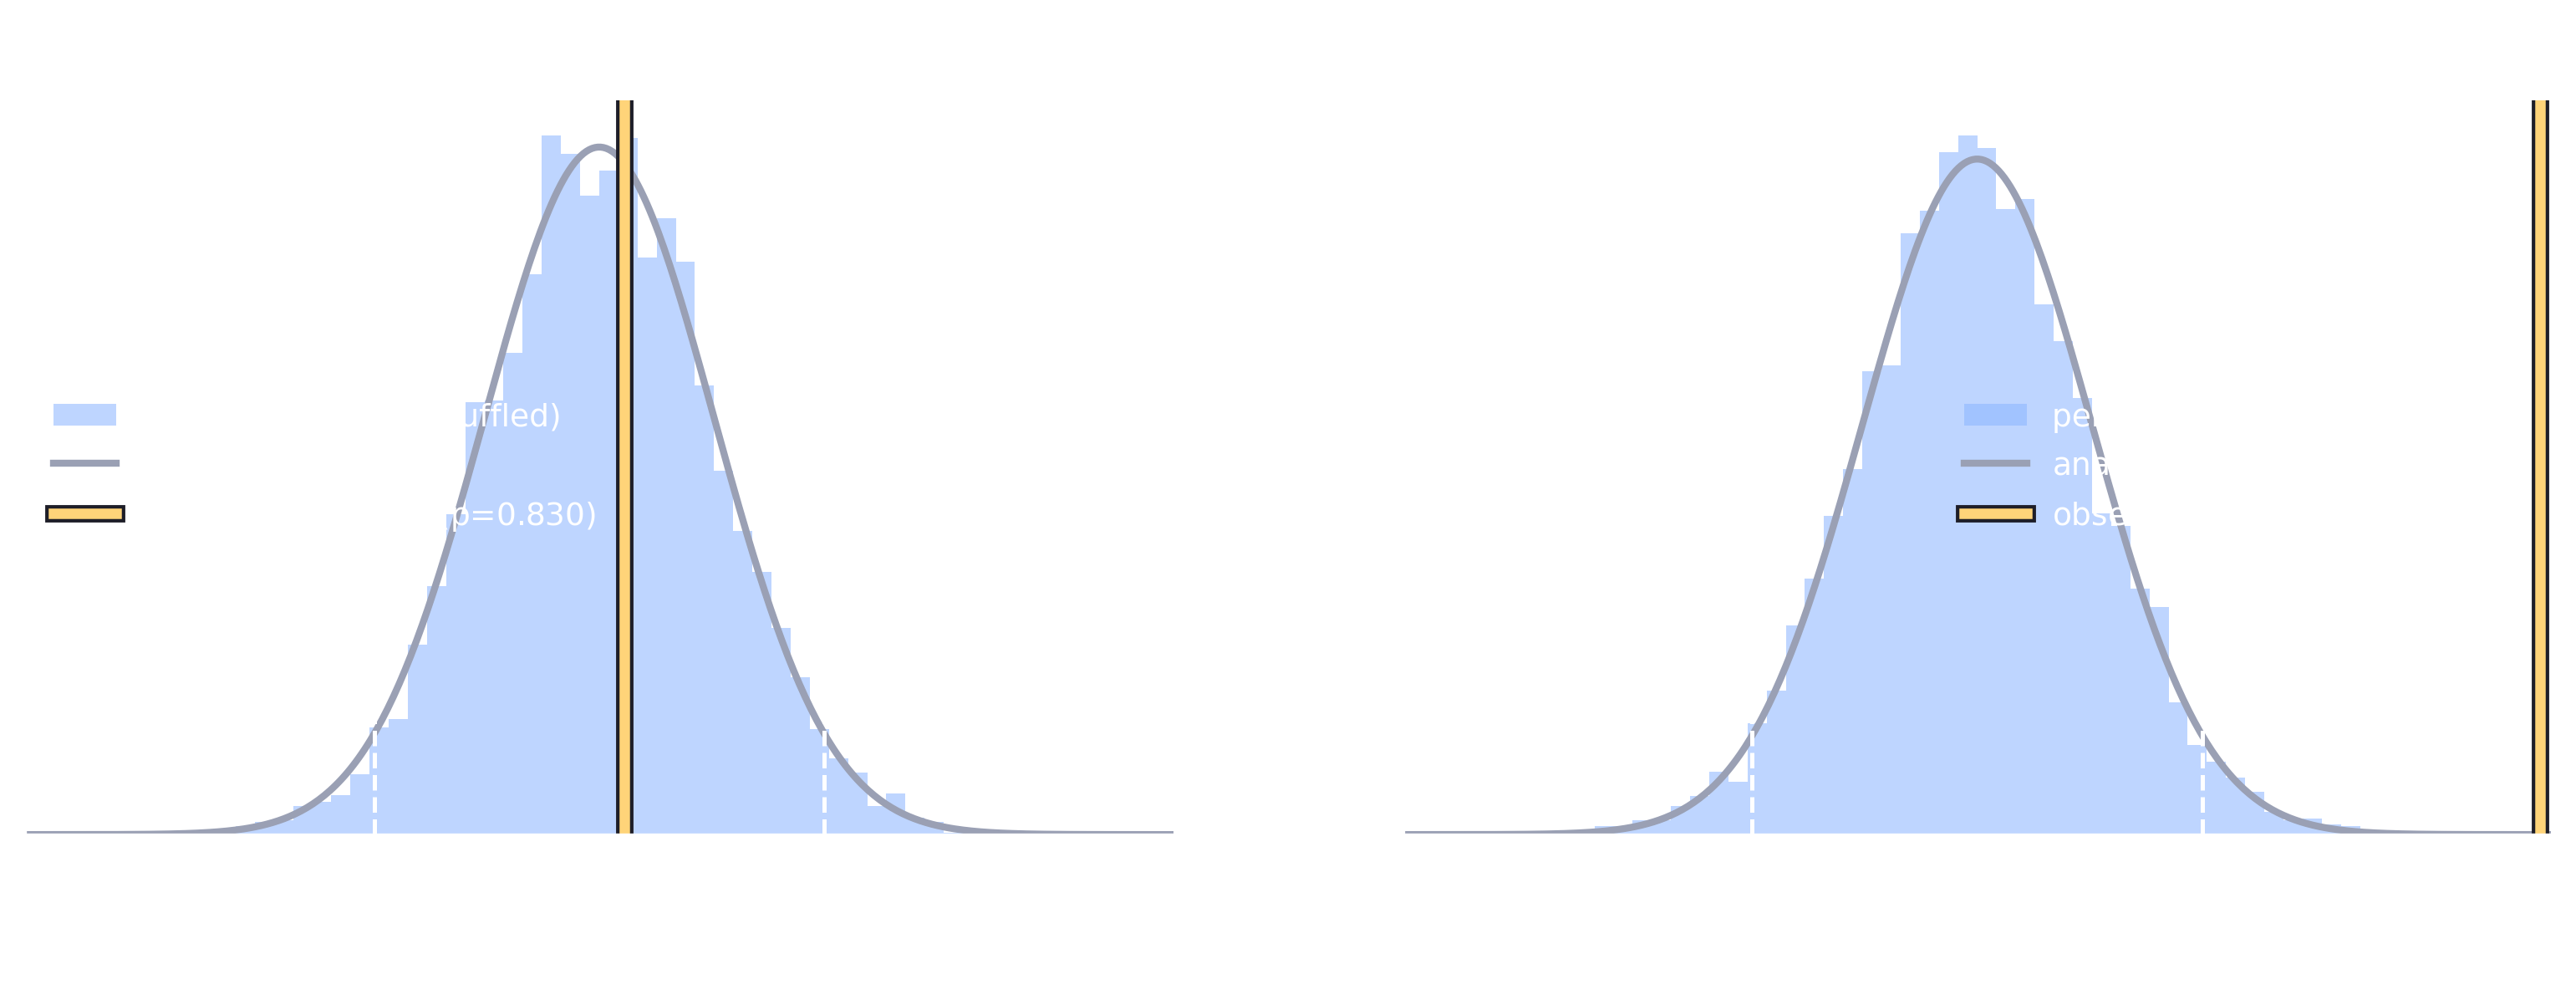

'slide_images/s2_permutation_var.png'

In [162]:
def panel6v(ax, s1, s2, title, xr=5):
    pooled = np.concatenate([s1, s2]); n1 = len(s1); n2 = len(s2); N = n1 + n2
    idx = np.argsort(rng.random((P, N)), axis=1); sh = pooled[idx]; a = sh[:, :n1]; b = sh[:, n1:]
    def vse(g, n):
        m2 = g.var(ddof=1, axis=1); m4 = ((g - g.mean(1, keepdims=True))**4).mean(1)
        return m2, np.sqrt(np.maximum((m4 - m2**2)/n, 1e-12))
    m2a, sea = vse(a, n1); m2b, seb = vse(b, n2); Zp = (m2a - m2b) / np.sqrt(sea**2 + seb**2)
    ov1, se1 = obs_var_se(s1, n1); ov2, se2 = obs_var_se(s2, n2)
    obsZ = (ov1 - ov2) / np.sqrt(se1**2 + se2**2); pval = np.mean(np.abs(Zp) >= abs(obsZ))
    ax.hist(Zp, bins=60, range=(-xr, xr), density=True, color=BLUE, alpha=0.55, label="permutation null (shuffled)")
    x = np.linspace(-xr, xr, 400); ax.plot(x, stats.norm.pdf(x), color=GREY, lw=2, label=r"analytic $N(0,1)$")
    for xc in (1.96, -1.96): ax.axvline(xc, color="white", lw=1.2, ls="--")
    obsline(ax, np.clip(obsZ, -xr*0.98, xr*0.98), fr"observed $Z={obsZ:+.1f}$  (p={pval:.3f})"); ax.set_xlim(-xr, xr)
    ax.set_yticks([]); ax.set_xlabel(r"$Z=D/s_D$"); ax.set_title(title); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
panel6v(axes[0], A, B, r"$s_A^2$ vs $s_B^2$")
panel6v(axes[1], A, C, r"$s_A^2$ vs $s_C^2$")
save(fig, "s2_permutation_var")

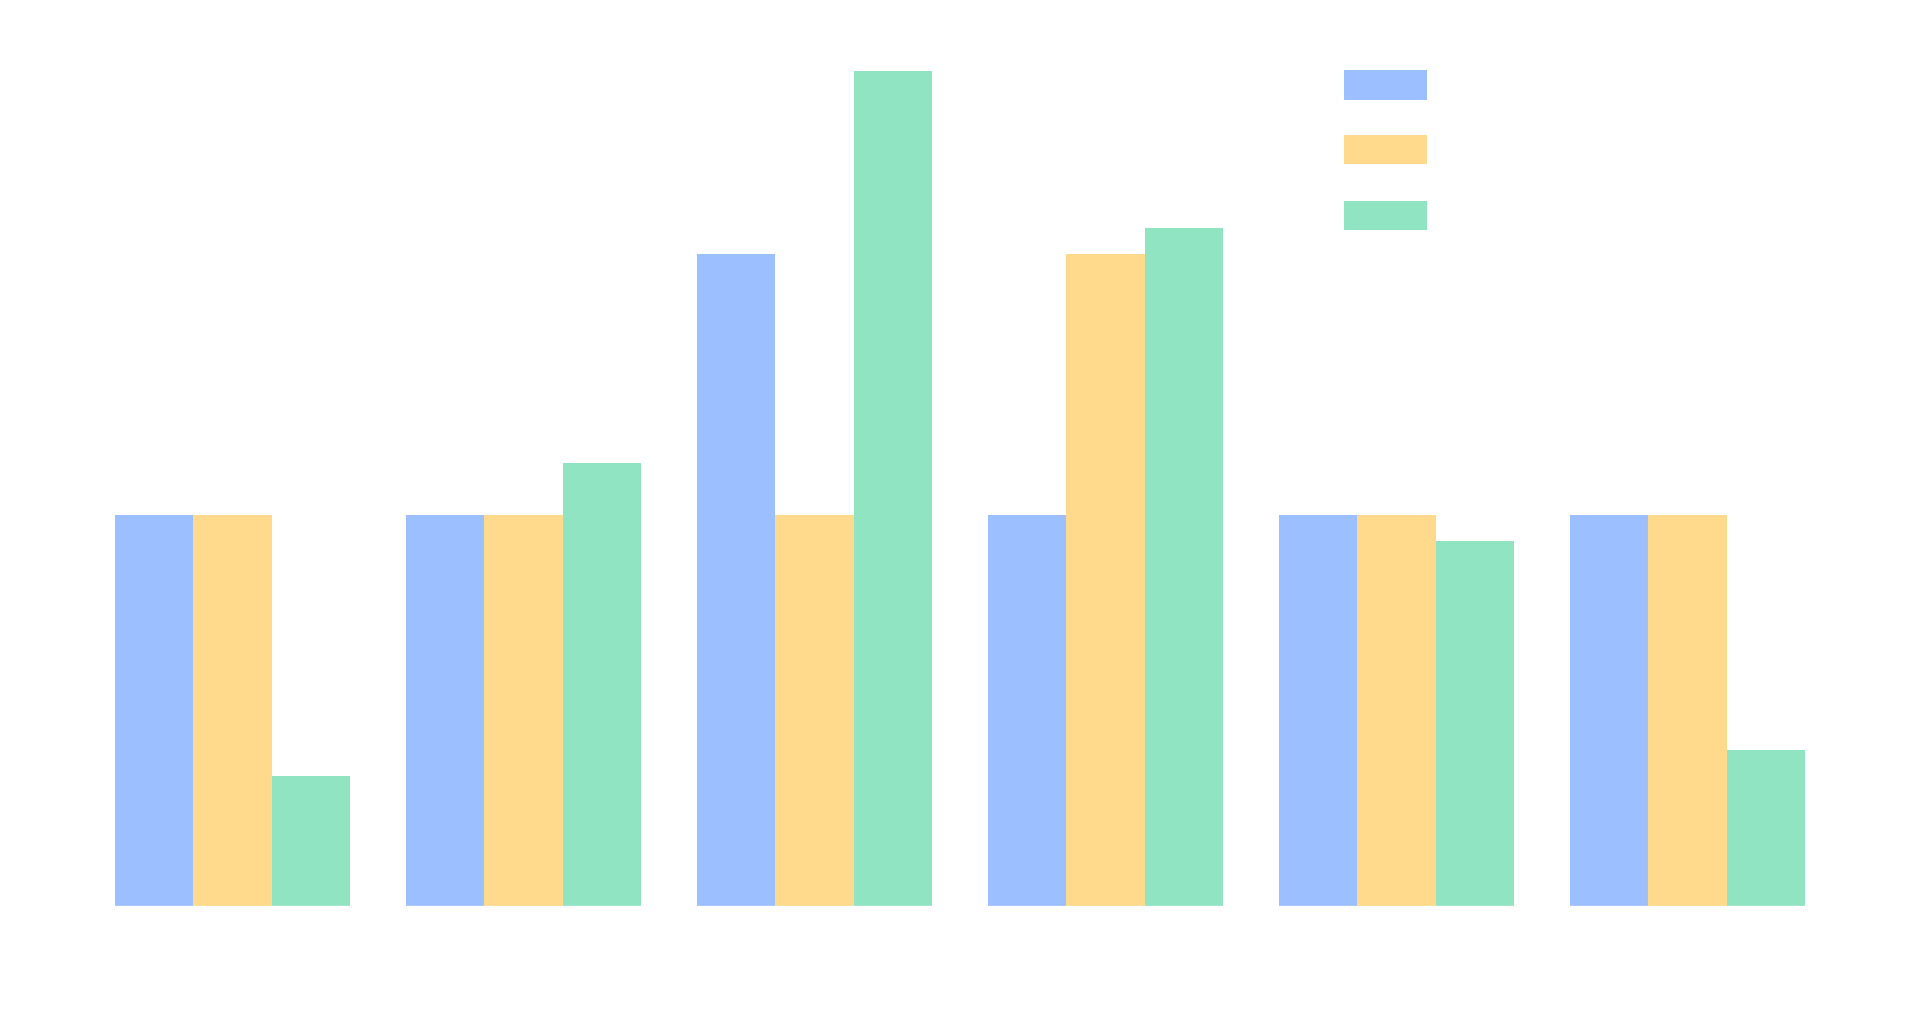

'slide_images/s2_samples_all.png'

In [165]:
def panel0_all(ax):
    w = 0.27
    for p, off, l, c in [(pA, -w, "A", BLUE), (pB, 0.0, "B", GOLD), (pC, w, "C", GREEN)]:
        m, s = moments(p)
        ax.bar(faces + off, p, width=w, color=c, alpha=0.85, label=fr"{l}:  $\mu={m:.2f},\ \sigma={s:.2f}$")
    ax.set_xticks(faces); ax.set_yticks([]); ax.legend(fontsize=10)

fig, ax = plt.subplots(figsize=(8, 3.8))
panel0_all(ax)
save(fig, "s2_samples_all")

## Two runs — false positives vs power
Sampling distribution of the Z statistic when $H_0$ is **true** (both $N(0,1)$) vs when there's a real gap of 0.5. Area past $\pm1.96$ = rejection: ~5% under $H_0$ (false positives), much more under $H_1$ (power).

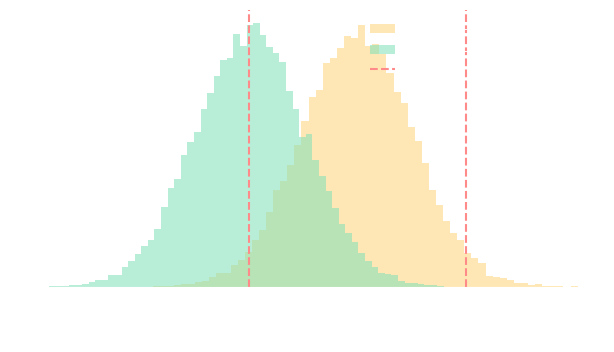

'slide_images/s2_errors.png'

In [28]:
R = 20000
def zstat(a, b): return (a.mean(1) - b.mean(1)) / np.sqrt(sd**2/nA + sd**2/nB)
z0 = zstat(rng.normal(0, sd, (R, nA)), rng.normal(0.0, sd, (R, nB)))   # H0 true
z1 = zstat(rng.normal(0, sd, (R, nA)), rng.normal(0.5, sd, (R, nB)))   # gap = 0.5
fpr = np.mean(np.abs(z0) > 1.96) * 100; power = np.mean(np.abs(z1) > 1.96) * 100
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(z0, bins=60, density=True, color=GOLD,  alpha=0.55, label=f"$H_0$ true — reject {fpr:.0f}%")
ax.hist(z1, bins=60, density=True, color=GREEN, alpha=0.55, label=f"gap 0.5 — reject {power:.0f}% (power)")
ax.axvline(1.96, color=RED, lw=1.5, ls="--"); ax.axvline(-1.96, color=RED, lw=1.5, ls="--", label=r"$\pm1.96$")
ax.set_yticks([]); ax.set_xlabel("Z statistic"); ax.legend(fontsize=9)
save(fig, "s2_errors")

## Power vs effect size and $n$  (the $\sqrt n$)
Power climbs with the true gap and with sample size; the $\sqrt n$ in the standard error is what drives the right-hand curve.

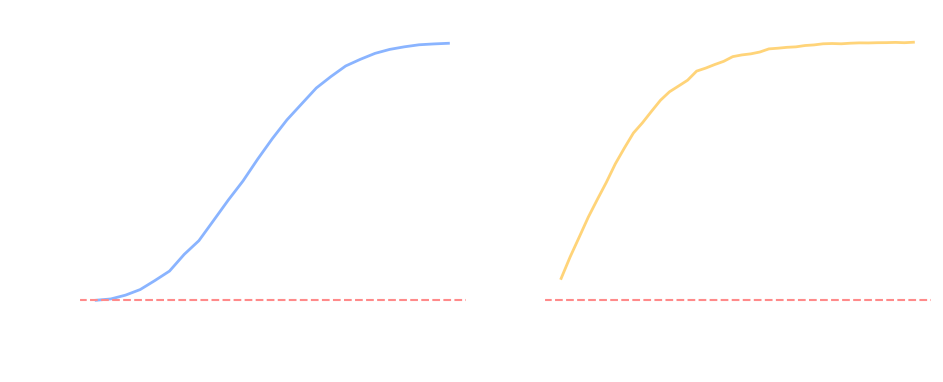

'slide_images/s2_power.png'

In [29]:
Rc = 8000
gaps = np.linspace(0, 1.2, 25); n_fix = 30
powg = [np.mean(np.abs((rng.normal(0,sd,(Rc,n_fix)).mean(1) - rng.normal(g,sd,(Rc,n_fix)).mean(1))
                       / np.sqrt(2*sd**2/n_fix)) > 1.96) for g in gaps]
ns = np.arange(5, 201, 5); gap_fix = 0.5
pown = [np.mean(np.abs((rng.normal(0,sd,(Rc,nn)).mean(1) - rng.normal(gap_fix,sd,(Rc,nn)).mean(1))
                       / np.sqrt(2*sd**2/nn)) > 1.96) for nn in ns]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(gaps, powg, color=BLUE, lw=2); a1.axhline(0.05, color=RED, ls="--")
a1.set_xlabel(r"true gap  $\mu_B-\mu_A$"); a1.set_ylabel("power"); a1.set_title("power vs effect size (n=30)")
a2.plot(ns, pown, color=GOLD, lw=2); a2.axhline(0.05, color=RED, ls="--")
a2.set_xlabel("n per group"); a2.set_title("power vs n (gap=0.5)")
for a in (a1, a2): a.set_ylim(0, 1.02)
save(fig, "s2_power")